## **Cost Overrun Prediction**
###**Aim:**

This research aims to develop an early-stage predictive framework for construction cost overrun predictions using the early-stage project data, and integrating them with the external economic indicators, then applying explainable AI techniques to improve interpretability and support decision-making.

### **Objectives:**

The following are the objectives of this study,

1.	To identify key pre-construction factors and external risk indicators influencing construction cost overruns.

2.	To develop a predictive machine learning framework using pre-construction data.

3.	To evaluate the contribution of external macroeconomic indicators through a two-variant ablation design.

4.	To develop and compare the results of multiple machine learning models

5.	To incorporate explainability techniques to interpret the outputs of the selected model



## **Research Design and Workflow:**

1. Data Collection
2. Data Preparation
3. Exploratory Data Analysis
4. Feature engineering
5. Model Development and Training
6. Hyperparameter Tuning
7. Final Model Evaluation and Analysis
8. SHAP Implementation
9. Conclusion
10. Insights and Recommendations

### **Step1 : Data Collection**

### Data Sources:

This study will use two publicly available datasets as primary sources which is available at no cost and no licensing requirements.

•	BIM-AI Integrated Dataset, consists of project level information

•	Total Construction Spending Data Collection, consists of external economic indicators

In [68]:
# Import necessary libraries
import os
import pandas as pd
from tqdm import tqdm
import zipfile
import matplotlib.pyplot as plt

In [69]:
# Load the files as documents

# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
# Create the Output Directory Structure to save outputs
import os

# Base directory in Google Drive
BASE_DIR = "/content/drive/MyDrive/CostOverrunPrediction"

# Subfolders
FIG_DIR = os.path.join(BASE_DIR, "outputs/figures")
TABLE_DIR = os.path.join(BASE_DIR, "outputs/tables")
MODEL_DIR = os.path.join(BASE_DIR, "models")
LOG_DIR = os.path.join(BASE_DIR, "outputs/logs")
SHAP_LOCAL_DIR = os.path.join(FIG_DIR, "shap_local_examples")

# Create all directories
for path in [BASE_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR, LOG_DIR, SHAP_LOCAL_DIR]:
    os.makedirs(path, exist_ok=True)

print("All output directories created successfully.")

All output directories created successfully.


#### 1.1 Upload the BIM-AI dataset and prepare for integration

In [71]:
# Uploading the BIM-AI dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/Cost_Overrun_Research/data/raw/bim_ai_civil_engineering_dataset.csv'

In [72]:
# Fetch the file

df_bim = pd.read_csv(file_path)


# Quick preview
print(f"Dataset loaded successfully!")
print(f"Shape: {df_bim.shape[0]} rows × {df_bim.shape[1]} columns")
print(f"\nFirst 5 rows:")
df_bim.head()



Dataset loaded successfully!
Shape: 1000 rows × 28 columns

First 5 rows:


,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,...,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,1.505450e+07,2.793720e+06,699,813.914852,...,25202.994687,244.843310,6602,76.300184,8,6.192198,52.988330,0,95.006343,High
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3.507054e+06,1.137777e+06,269,384.118221,...,49066.172542,263.123025,7121,63.527671,5,2.134473,50.885745,0,25.294824,Low
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,...,48192.547163,608.985023,9956,47.099444,2,3.113728,93.905836,0,97.478830,Medium
3,PJT_4,Dam,Houston,2020-01-04,2022-04-12,24499306,2.946966e+07,4.970354e+06,809,974.565655,...,19811.151750,673.574344,3725,86.846394,5,4.070101,90.454316,1,95.098131,High
4,PJT_5,Dam,Seattle,2020-01-05,2022-02-12,1749971,2.329338e+06,5.793670e+05,354,347.990127,...,44866.565169,765.476122,4368,61.827163,6,2.759351,78.391069,0,43.624985,Low


In [73]:
# Initial Sanity checks

# Display basic info
print("=== DATASET OVERVIEW ===\n")
print(f"Total rows: {df_bim.shape[0]}")
print(f"Total columns: {df_bim.shape[1]}")
print(f"\nColumn data types:")
print(df_bim.dtypes)


=== DATASET OVERVIEW ===

Total rows: 1000
Total columns: 28

Column data types:
Project_ID                object
Project_Type              object
Location                  object
Start_Date                object
End_Date                  object
Planned_Cost               int64
Actual_Cost              float64
Cost_Overrun             float64
Planned_Duration           int64
Actual_Duration          float64
Schedule_Deviation       float64
Vibration_Level          float64
Crack_Width              float64
Load_Bearing_Capacity    float64
Temperature              float64
Humidity                 float64
Weather_Condition         object
Air_Quality_Index          int64
Energy_Consumption       float64
Material_Usage           float64
Labor_Hours                int64
Equipment_Utilization    float64
Accident_Count             int64
Safety_Risk_Score        float64
Image_Analysis_Score     float64
Anomaly_Detected           int64
Completion_Percentage    float64
Risk_Level                ob

In [74]:
# Check missing values

missing = df_bim.isnull().sum()
missing_pct = (missing / len(df_bim)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_summary[missing_summary['Missing Count'] > 0])


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [75]:
# Convert Start_Date to pandas datetime
df_bim['Start_Date'] = pd.to_datetime(df_bim['Start_Date'], errors='coerce')

# Verify conversion
print("=== DATE STANDARDIZATION ===")
print(f"Data type: {df_bim['Start_Date'].dtype}")
print(f"Earliest date: {df_bim['Start_Date'].min()}")
print(f"Latest date: {df_bim['Start_Date'].max()}")
print(f"Invalid dates: {df_bim['Start_Date'].isnull().sum()}")

=== DATE STANDARDIZATION ===
Data type: datetime64[ns]
Earliest date: 2020-01-01 00:00:00
Latest date: 2022-09-26 00:00:00
Invalid dates: 0


In [76]:
# Create Project_Month (first day of project's start month)
df_bim['Project_Month'] = df_bim['Start_Date'].dt.to_period('M').dt.to_timestamp()

# Display sample
print("\n=== PROJECT_MONTH SAMPLE ===")
print(df_bim[['Start_Date', 'Project_Month']].head(10))

# Distribution by month
print("\n=== PROJECT DISTRIBUTION BY MONTH (top 12) ===")
print(df_bim['Project_Month'].value_counts().sort_index().head(12))


=== PROJECT_MONTH SAMPLE ===
  Start_Date Project_Month
0 2020-01-01    2020-01-01
1 2020-01-02    2020-01-01
2 2020-01-03    2020-01-01
3 2020-01-04    2020-01-01
4 2020-01-05    2020-01-01
5 2020-01-06    2020-01-01
6 2020-01-07    2020-01-01
7 2020-01-08    2020-01-01
8 2020-01-09    2020-01-01
9 2020-01-10    2020-01-01

=== PROJECT DISTRIBUTION BY MONTH (top 12) ===
Project_Month
2020-01-01    31
2020-02-01    29
2020-03-01    31
2020-04-01    30
2020-05-01    31
2020-06-01    30
2020-07-01    31
2020-08-01    31
2020-09-01    30
2020-10-01    31
2020-11-01    30
2020-12-01    31
Name: count, dtype: int64


In [77]:
# Check the date range
print(f"\n=== TEMPORAL COVERAGE ===")
print(f"Earliest Project_Month: {df_bim['Project_Month'].min()}")
print(f"Latest Project_Month: {df_bim['Project_Month'].max()}")
print(f"\nProject distribution by year:")
print(df_bim['Start_Date'].dt.year.value_counts().sort_index())


=== TEMPORAL COVERAGE ===
Earliest Project_Month: 2020-01-01 00:00:00
Latest Project_Month: 2022-09-01 00:00:00

Project distribution by year:
Start_Date
2020    366
2021    365
2022    269
Name: count, dtype: int64


### 1.2.Upload Economic Indicators Datasets

In [78]:
# Define economic data path
economic_path = '/content/drive/MyDrive/Colab Notebooks/Cost_Overrun_Research/data/raw/economic/'

# List files in directory
if os.path.exists(economic_path):
    files = os.listdir(economic_path)
    print(f"Files in economic data folder:")
    for f in files:
        file_full = os.path.join(economic_path, f)
        size_kb = os.path.getsize(file_full) / 1024
        print(f"  - {f} ({size_kb:.2f} KB)")
else:
    print(f"Path does not exist. Please upload economic files first.")
    print(f"   Expected path: {economic_path}")


Files in economic data folder:
  - TTLCONS.csv (7.25 KB)
  - TLRESCONS.csv (5.16 KB)
  - TLNRESCONS.csv (5.20 KB)
  - MPCTXXXXS.csv (4.39 KB)


In [79]:
# Load each economic indicator file
ttlcons = pd.read_csv(os.path.join(economic_path, 'TTLCONS.csv'))
tlrescons = pd.read_csv(os.path.join(economic_path, 'TLRESCONS.csv'))
tlnrescons = pd.read_csv(os.path.join(economic_path, 'TLNRESCONS.csv'))
mpct = pd.read_csv(os.path.join(economic_path, 'MPCTXXXXS.csv'))

print("=== ECONOMIC FILES LOADED ===\n")
print(f"TTLCONS shape:    {ttlcons.shape}")
print(f"TLRESCONS shape:  {tlrescons.shape}")
print(f"TLNRESCONS shape: {tlnrescons.shape}")
print(f"MPCTXXXXS shape:  {mpct.shape}")

=== ECONOMIC FILES LOADED ===

TTLCONS shape:    (400, 2)
TLRESCONS shape:  (292, 2)
TLNRESCONS shape: (292, 2)
MPCTXXXXS shape:  (291, 2)


In [13]:
# Inspect each file structure
print("=== TTLCONS STRUCTURE ===")
print(f"Columns: {ttlcons.columns.tolist()}")
print(f"Data types:\n{ttlcons.dtypes}")
print(f"\nFirst 5 rows:")
print(ttlcons.head())

print("\n=== TLRESCONS STRUCTURE ===")
print(f"Columns: {tlrescons.columns.tolist()}")
print(tlrescons.head())

print("\n=== TLNRESCONS STRUCTURE ===")
print(f"Columns: {tlnrescons.columns.tolist()}")
print(tlnrescons.head())

print("\n=== MPCTXXXXS STRUCTURE ===")
print(f"Columns: {mpct.columns.tolist()}")
print(mpct.head())

=== TTLCONS STRUCTURE ===
Columns: ['observation_date', 'TTLCONS']
Data types:
observation_date    object
TTLCONS              int64
dtype: object

First 5 rows:
  observation_date  TTLCONS
0       1993-01-01   458080
1       1993-02-01   462967
2       1993-03-01   458399
3       1993-04-01   469425
4       1993-05-01   468998

=== TLRESCONS STRUCTURE ===
Columns: ['observation_date', 'TLRESCONS']
  observation_date  TLRESCONS
0       2002-01-01     382979
1       2002-02-01     391434
2       2002-03-01     390942
3       2002-04-01     404255
4       2002-05-01     399164

=== TLNRESCONS STRUCTURE ===
Columns: ['observation_date', 'TLNRESCONS']
  observation_date  TLNRESCONS
0       2002-01-01      475704
1       2002-02-01      470946
2       2002-03-01      453504
3       2002-04-01      453776
4       2002-05-01      451789

=== MPCTXXXXS STRUCTURE ===
Columns: ['observation_date', 'MPCTXXXXS']
  observation_date  MPCTXXXXS
0       2002-02-01        0.4
1       2002-03-01       -

#### 1.2.1. Standardize the Excel Files

In [80]:
import os
import pandas as pd

economic_path = '/content/drive/MyDrive/Colab Notebooks/Cost_Overrun_Research/data/raw/economic/'

def prepare_fred_indicator_v2(filepath, new_name):
    """
    Standardize FRED two-column CSV files.

    Input columns: ['observation_date', <series_specific_value_column>]
    Output: DataFrame with ['Date', new_name]
    """
    df = pd.read_csv(filepath)

    # Identify the date column (FRED uses 'observation_date' or 'DATE')
    date_col = None
    for candidate in ['observation_date', 'DATE', 'date']:
        if candidate in df.columns:
            date_col = candidate
            break

    if date_col is None:
        raise ValueError(f"No date column found in {filepath}")

    # The value column is the OTHER column (not the date)
    value_col = [c for c in df.columns if c != date_col][0]

    # Convert date to datetime
    df['Date'] = pd.to_datetime(df[date_col], errors='coerce')

    # Convert value to numeric (FRED sometimes uses '.' for missing)
    df[new_name] = pd.to_numeric(df[value_col].astype(str).replace('.', None), errors='coerce')

    # Keep only relevant columns
    df = df[['Date', new_name]]

    # Sort by date
    df = df.sort_values('Date').reset_index(drop=True)

    return df


# Apply to each FRED file
ttlcons_clean = prepare_fred_indicator_v2(
    os.path.join(economic_path, 'TTLCONS.csv'),
    'total_construction_spending'
)

tlrescons_clean = prepare_fred_indicator_v2(
    os.path.join(economic_path, 'TLRESCONS.csv'),
    'residential_construction_spending'
)

tlnrescons_clean = prepare_fred_indicator_v2(
    os.path.join(economic_path, 'TLNRESCONS.csv'),
    'nonresidential_construction_spending'
)

mpct_clean = prepare_fred_indicator_v2(
    os.path.join(economic_path, 'MPCTXXXXS.csv'),
    'construction_pct_change'
)

# Verify each
print("=== STANDARDIZED FRED FILES ===\n")
for name, df in [
    ('TTLCONS', ttlcons_clean),
    ('TLRESCONS', tlrescons_clean),
    ('TLNRESCONS', tlnrescons_clean),
    ('MPCTXXXXS', mpct_clean)
]:
    print(f"{name}:")
    print(f"  Shape: {df.shape}")
    print(f"  Range: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
    print(f"  Missing values: {df.iloc[:, 1].isnull().sum()}")
    print(f"  First 3 rows:")
    print(df.head(3).to_string(index=False))
    print()

=== STANDARDIZED FRED FILES ===

TTLCONS:
  Shape: (400, 2)
  Range: 1993-01 to 2026-04
  Missing values: 0
  First 3 rows:
      Date  total_construction_spending
1993-01-01                       458080
1993-02-01                       462967
1993-03-01                       458399

TLRESCONS:
  Shape: (292, 2)
  Range: 2002-01 to 2026-04
  Missing values: 0
  First 3 rows:
      Date  residential_construction_spending
2002-01-01                             382979
2002-02-01                             391434
2002-03-01                             390942

TLNRESCONS:
  Shape: (292, 2)
  Range: 2002-01 to 2026-04
  Missing values: 0
  First 3 rows:
      Date  nonresidential_construction_spending
2002-01-01                                475704
2002-02-01                                470946
2002-03-01                                453504

MPCTXXXXS:
  Shape: (291, 2)
  Range: 2002-02 to 2026-04
  Missing values: 0
  First 3 rows:
      Date  construction_pct_change
2002-02-01       

### **Step 2: Data Preparation**

##### **2.1 Data Integration**

In [81]:
# Merge all 4 indicators using outer join
economic_combined = ttlcons_clean.merge(
    tlrescons_clean, on='Date', how='outer'
).merge(
    tlnrescons_clean, on='Date', how='outer'
).merge(
    mpct_clean, on='Date', how='outer'
)

# Sort by date
economic_combined = economic_combined.sort_values('Date').reset_index(drop=True)

print("=== COMBINED ECONOMIC DATA (BEFORE CLEANING) ===\n")
print(f"Shape: {economic_combined.shape}")
print(f"Date range: {economic_combined['Date'].min().strftime('%Y-%m')} to {economic_combined['Date'].max().strftime('%Y-%m')}")
print(f"\nMissing values per column:")
print(economic_combined.isnull().sum())

=== COMBINED ECONOMIC DATA (BEFORE CLEANING) ===

Shape: (400, 5)
Date range: 1993-01 to 2026-04

Missing values per column:
Date                                      0
total_construction_spending               0
residential_construction_spending       108
nonresidential_construction_spending    108
construction_pct_change                 109
dtype: int64


In [82]:
# Trim only leading rows; preserve all tail observations

economic_cols = [
    'total_construction_spending',
    'residential_construction_spending',
    'nonresidential_construction_spending',
    'construction_pct_change'
]

# Find the first date where ALL 4 series have valid values
all_valid_mask = economic_combined[economic_cols].notna().all(axis=1)
first_all_valid = economic_combined[all_valid_mask]['Date'].min()

print(f"First date where ALL series have valid values: {first_all_valid.strftime('%Y-%m')}")

# Trim ONLY leading rows
economic_cleaned = economic_combined[economic_combined['Date'] >= first_all_valid].copy()
economic_cleaned = economic_cleaned.reset_index(drop=True)

# Defensive forward-fill for any internal gaps (should be none)
economic_cleaned = economic_cleaned.ffill()

# Verify
print(f"\n=== CLEANED ECONOMIC DATA ===")
print(f"Shape: {economic_cleaned.shape}")
print(f"Date range: {economic_cleaned['Date'].min().strftime('%Y-%m')} to {economic_cleaned['Date'].max().strftime('%Y-%m')}")
print(f"Missing values: {economic_cleaned.isnull().sum().sum()}")

# Critical: Verify tail is preserved
print(f"\n=== LAST 5 ROWS (TAIL VERIFICATION) ===")
print(economic_cleaned.tail(5).to_string(index=False))

First date where ALL series have valid values: 2002-02

=== CLEANED ECONOMIC DATA ===
Shape: (291, 5)
Date range: 2002-02 to 2026-04
Missing values: 0

=== LAST 5 ROWS (TAIL VERIFICATION) ===
      Date  total_construction_spending  residential_construction_spending  nonresidential_construction_spending  construction_pct_change
2025-12-01                      2219926                           971295.0                             1248631.0                      1.8
2026-01-01                      2178092                           927464.0                             1250627.0                     -1.9
2026-02-01                      2160663                           909596.0                             1251067.0                     -0.8
2026-03-01                      2164474                           914948.0                             1249526.0                      0.2
2026-04-01                      2172397                           922037.0                             1250361.0      

###### Check Verify Coverage

In [83]:
# Verify Coverage for Project Months

df_bim['Project_Month'] = pd.to_datetime(df_bim['Project_Month'])

print("=== TEMPORAL COVERAGE VERIFICATION ===\n")
print(f"Project date range: {df_bim['Project_Month'].min().strftime('%Y-%m')} to {df_bim['Project_Month'].max().strftime('%Y-%m')}")
print(f"Economic data range: {economic_cleaned['Date'].min().strftime('%Y-%m')} to {economic_cleaned['Date'].max().strftime('%Y-%m')}")

# Check coverage
project_months = set(df_bim['Project_Month'].unique())
economic_months = set(economic_cleaned['Date'].unique())

uncovered = project_months - economic_months
covered = project_months & economic_months

print(f"\nUnique project months: {len(project_months)}")
print(f"Covered by economic data: {len(covered)}")
print(f"Uncovered: {len(uncovered)}")

if len(uncovered) == 0:
    print(f"\nCOMPLETE COVERAGE: All project months covered!")
else:
    print(f"\nUncovered months:")
    for m in sorted(uncovered):
        print(f"   - {m}")

=== TEMPORAL COVERAGE VERIFICATION ===

Project date range: 2020-01 to 2022-09
Economic data range: 2002-02 to 2026-04

Unique project months: 33
Covered by economic data: 33
Uncovered: 0

COMPLETE COVERAGE: All project months covered!


###### Merge BIM-AI with Economic Data

In [84]:
# Left join: keep all BIM-AI projects, add economic indicators
df_master = df_bim.merge(
    economic_cleaned,
    left_on='Project_Month',
    right_on='Date',
    how='left'
)

# Drop the redundant Date column
df_master = df_master.drop('Date', axis=1)

print("=== MASTER DATASET CREATED ===\n")
print(f"Shape: {df_master.shape}")
print(f"\nColumns: {df_master.columns.tolist()}")

# Verify no missing values
print(f"\n=== MISSING VALUES CHECK ===")
missing = df_master[economic_cols].isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nAll economic values populated for every project")
else:
    print(f"\nMissing values found — investigation needed")

=== MASTER DATASET CREATED ===

Shape: (1000, 33)

Columns: ['Project_ID', 'Project_Type', 'Location', 'Start_Date', 'End_Date', 'Planned_Cost', 'Actual_Cost', 'Cost_Overrun', 'Planned_Duration', 'Actual_Duration', 'Schedule_Deviation', 'Vibration_Level', 'Crack_Width', 'Load_Bearing_Capacity', 'Temperature', 'Humidity', 'Weather_Condition', 'Air_Quality_Index', 'Energy_Consumption', 'Material_Usage', 'Labor_Hours', 'Equipment_Utilization', 'Accident_Count', 'Safety_Risk_Score', 'Image_Analysis_Score', 'Anomaly_Detected', 'Completion_Percentage', 'Risk_Level', 'Project_Month', 'total_construction_spending', 'residential_construction_spending', 'nonresidential_construction_spending', 'construction_pct_change']

=== MISSING VALUES CHECK ===
total_construction_spending             0
residential_construction_spending       0
nonresidential_construction_spending    0
construction_pct_change                 0
dtype: int64

All economic values populated for every project


###### Dataset Validation

In [85]:
# Master Dataset Validation
print("=== MASTER DATASET VALIDATION ===\n")

# Check 1: Total rows preserved
print(f"✓ Total rows: {len(df_master)} (expected: 1000)")
assert len(df_master) == 1000, "Row count mismatch!"

# Check 2: All required columns present
required_cols = [
    'Project_ID', 'Project_Type', 'Location', 'Planned_Cost', 'Planned_Duration',
    'Start_Date', 'Project_Month',
    'total_construction_spending', 'residential_construction_spending',
    'nonresidential_construction_spending', 'construction_pct_change'
]
missing_cols = [c for c in required_cols if c not in df_master.columns]
if missing_cols:
    print(f"Missing columns: {missing_cols}")
else:
    print(f"All required columns present ({len(required_cols)} columns)")

# Check 3: No missing values
missing_values = df_master[required_cols].isnull().sum()
if missing_values.sum() > 0:
    print(f"Missing values:")
    print(missing_values[missing_values > 0])
else:
    print(f"No missing values in required columns")


# Check 5: Economic indicator statistics
print(f"\n=== ECONOMIC INDICATOR STATISTICS ===")
print(df_master[economic_cols].describe())

=== MASTER DATASET VALIDATION ===

✓ Total rows: 1000 (expected: 1000)
All required columns present (11 columns)
No missing values in required columns

=== ECONOMIC INDICATOR STATISTICS ===
       total_construction_spending  residential_construction_spending  \
count                 1.000000e+03                        1000.000000   
mean                  1.662628e+06                      786787.622000   
std                   1.612532e+05                      127901.594319   
min                   1.449765e+06                      593736.000000   
25%                   1.512309e+06                      673737.000000   
50%                   1.627889e+06                      790176.000000   
75%                   1.808519e+06                      909346.000000   
max                   1.925882e+06                      988269.000000   

       nonresidential_construction_spending  construction_pct_change  
count                          1.000000e+03               1000.00000  
mean      

Coverage Verification After Integration:

- All unique Project_Month values in the BIM-AI dataset are present in the FRED dataset.

- No missing values exist in any of the four economic indicator columns after the merge.

- All project records are retained in the master dataset.


In [86]:
# Spot check
print("\n=== SPOT CHECK: 3 RANDOM PROJECTS ===\n")

sample_projects = df_master.sample(3, random_state=42)

for idx, row in sample_projects.iterrows():
    print(f"Project: {row['Project_ID']}, Month: {row['Project_Month'].strftime('%Y-%m')}")
    print(f"  TTLCONS: {row['total_construction_spending']}")
    print(f"  TLRESCONS: {row['residential_construction_spending']}")
    print(f"  TLNRESCONS: {row['nonresidential_construction_spending']}")
    print(f"  MPCTXXXXS: {row['construction_pct_change']:.4f}")
    print()


=== SPOT CHECK: 3 RANDOM PROJECTS ===

Project: PJT_522, Month: 2021-06
  TTLCONS: 1639031
  TLRESCONS: 800589.0
  TLNRESCONS: 838443.0
  MPCTXXXXS: 0.7000

Project: PJT_738, Month: 2022-01
  TTLCONS: 1808519
  TLRESCONS: 923595.0
  TLNRESCONS: 884924.0
  MPCTXXXXS: 2.6000

Project: PJT_741, Month: 2022-01
  TTLCONS: 1808519
  TLRESCONS: 923595.0
  TLNRESCONS: 884924.0
  MPCTXXXXS: 2.6000



In [87]:
# Verify the data

df_master.head(10)

,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,...,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level,Project_Month,total_construction_spending,residential_construction_spending,nonresidential_construction_spending,construction_pct_change
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,1.505450e+07,2.793720e+06,699,813.914852,...,6.192198,52.988330,0,95.006343,High,2020-01-01,1491029,606865.0,884163.0,1.5
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3.507054e+06,1.137777e+06,269,384.118221,...,2.134473,50.885745,0,25.294824,Low,2020-01-01,1491029,606865.0,884163.0,1.5
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,...,3.113728,93.905836,0,97.478830,Medium,2020-01-01,1491029,606865.0,884163.0,1.5
3,PJT_4,Dam,Houston,2020-01-04,2022-04-12,24499306,2.946966e+07,4.970354e+06,809,974.565655,...,4.070101,90.454316,1,95.098131,High,2020-01-01,1491029,606865.0,884163.0,1.5
4,PJT_5,Dam,Seattle,2020-01-05,2022-02-12,1749971,2.329338e+06,5.793670e+05,354,347.990127,...,2.759351,78.391069,0,43.624985,Low,2020-01-01,1491029,606865.0,884163.0,1.5
5,PJT_6,Road,Seattle,2020-01-06,2020-09-18,16711072,2.368935e+07,6.978281e+06,255,379.859150,...,2.351205,99.936163,0,98.459226,Low,2020-01-01,1491029,606865.0,884163.0,1.5
6,PJT_7,Building,Los Angeles,2020-01-07,2021-11-25,47109273,4.746511e+07,3.558336e+05,792,831.587118,...,1.523780,97.652604,0,13.225974,Low,2020-01-01,1491029,606865.0,884163.0,1.5
7,PJT_8,Building,New York,2020-01-08,2021-09-19,42776934,5.903226e+07,1.625532e+07,842,794.863527,...,8.857923,82.755449,0,69.467550,High,2020-01-01,1491029,606865.0,884163.0,1.5
8,PJT_9,Building,Houston,2020-01-09,2021-03-17,25527188,3.143990e+07,5.912716e+06,579,751.477007,...,3.600491,73.228728,0,33.953302,Medium,2020-01-01,1491029,606865.0,884163.0,1.5
9,PJT_10,Dam,Los Angeles,2020-01-10,2021-05-23,5460276,6.213424e+06,7.531479e+05,250,314.304956,...,3.612885,57.608536,0,21.651679,Medium,2020-01-01,1491029,606865.0,884163.0,1.5


#### **2.2 Structural Validation**





###### Duplicate Detection and Handling

In [88]:
# Detect duplicate values

print("=== DUPLICATE DETECTION ===\n")

# Check for exact duplicates
total_rows = len(df_master)
duplicate_rows = df_master.duplicated().sum()

print(f"Total rows: {total_rows}")
print(f"Exact duplicate rows: {duplicate_rows}")

# Check for duplicate Project_IDs
duplicate_ids = df_master['Project_ID'].duplicated().sum()
print(f"Duplicate Project_IDs: {duplicate_ids}")

# Remove exact duplicates if any
if duplicate_rows > 0:
    df_master = df_master.drop_duplicates()
    print(f" Removed {duplicate_rows} duplicates. New shape: {df_master.shape}")
else:
    print(" No duplicates found")

# Verify unique Project_IDs
assert df_master['Project_ID'].nunique() == len(df_master), "❌ Duplicate Project_IDs exist!"
print(f" All Project_IDs are unique")

=== DUPLICATE DETECTION ===

Total rows: 1000
Exact duplicate rows: 0
Duplicate Project_IDs: 0
 No duplicates found
 All Project_IDs are unique


###### Datatype Enforcement

In [89]:
# Check Data types

print("=== DATA TYPE ENFORCEMENT ===\n")

# Define expected types for each column
expected_types = {
    'Project_ID': 'object',
    'Project_Type': 'object',
    'Location': 'object',
    'Start_Date': 'datetime64[ns]',
    'Project_Month': 'datetime64[ns]',
    'Planned_Cost': 'int64',
    'Planned_Duration': 'int64',
    'total_construction_spending': 'float64',
    'residential_construction_spending': 'float64',
    'nonresidential_construction_spending': 'float64',
    'construction_pct_change': 'float64',
}

# Check current types vs expected
print("Type verification:")
for col, expected_type in expected_types.items():
    if col in df_master.columns:
        current_type = str(df_master[col].dtype)
        status = "✓" if current_type == expected_type else "⚠️"
        print(f"  {status} {col}: {current_type} (expected: {expected_type})")

=== DATA TYPE ENFORCEMENT ===

Type verification:
  ✓ Project_ID: object (expected: object)
  ✓ Project_Type: object (expected: object)
  ✓ Location: object (expected: object)
  ✓ Start_Date: datetime64[ns] (expected: datetime64[ns])
  ✓ Project_Month: datetime64[ns] (expected: datetime64[ns])
  ✓ Planned_Cost: int64 (expected: int64)
  ✓ Planned_Duration: int64 (expected: int64)
  ⚠️ total_construction_spending: int64 (expected: float64)
  ✓ residential_construction_spending: float64 (expected: float64)
  ✓ nonresidential_construction_spending: float64 (expected: float64)
  ✓ construction_pct_change: float64 (expected: float64)


In [90]:
# Convert the datatype
df_master['total_construction_spending'] = df_master['total_construction_spending'].astype('float64')

In [91]:
# Verify after conversion
print("\n=== AFTER TYPE ENFORCEMENT ===")
print(df_master.dtypes)



=== AFTER TYPE ENFORCEMENT ===
Project_ID                                      object
Project_Type                                    object
Location                                        object
Start_Date                              datetime64[ns]
End_Date                                        object
Planned_Cost                                     int64
Actual_Cost                                    float64
Cost_Overrun                                   float64
Planned_Duration                                 int64
Actual_Duration                                float64
Schedule_Deviation                             float64
Vibration_Level                                float64
Crack_Width                                    float64
Load_Bearing_Capacity                          float64
Temperature                                    float64
Humidity                                       float64
Weather_Condition                               object
Air_Quality_Index                

###### Missing Value Analysis

In [92]:
# Check for Missing values
print("=== MISSING VALUE FINAL CHECK ===\n")

missing_check = df_master.isnull().sum()
print(missing_check)

if missing_check.sum() == 0:
    print("\nNo missing values in any column")
else:
    print(f"\n{missing_check.sum()} missing values found — investigate before proceeding")

=== MISSING VALUE FINAL CHECK ===

Project_ID                              0
Project_Type                            0
Location                                0
Start_Date                              0
End_Date                                0
Planned_Cost                            0
Actual_Cost                             0
Cost_Overrun                            0
Planned_Duration                        0
Actual_Duration                         0
Schedule_Deviation                      0
Vibration_Level                         0
Crack_Width                             0
Load_Bearing_Capacity                   0
Temperature                             0
Humidity                                0
Weather_Condition                       0
Air_Quality_Index                       0
Energy_Consumption                      0
Material_Usage                          0
Labor_Hours                             0
Equipment_Utilization                   0
Accident_Count                          0

Structural validation was implemented to confirm the integrity of the dataset after the data preparation activities. The validation confirmed that the total row count is preserved at 1000 records, all required columns are present, and no missing values in any column.  

###### Categorical Normalization

In [93]:
# categorical Normalization
print("=== CATEGORICAL NORMALIZATION ===\n")

# Check Project_Type categories
print("Project_Type categories:")
print(df_master['Project_Type'].value_counts())
print(f"  Unique values: {df_master['Project_Type'].nunique()}\n")

# Check Location categories
print("Location categories:")
print(df_master['Location'].value_counts())
print(f"  Unique values: {df_master['Location'].nunique()}\n")

=== CATEGORICAL NORMALIZATION ===

Project_Type categories:
Project_Type
Bridge      210
Tunnel      206
Dam         204
Building    190
Road        190
Name: count, dtype: int64
  Unique values: 5

Location categories:
Location
Los Angeles    211
New York       205
Seattle        205
Houston        190
Chicago        189
Name: count, dtype: int64
  Unique values: 5



In [94]:
# Normalize categorical values (strip whitespace, standardize case)
df_master['Project_Type'] = df_master['Project_Type'].str.strip().str.title()
df_master['Location'] = df_master['Location'].str.strip().str.title()

# Recheck after normalization
print("=== AFTER NORMALIZATION ===\n")
print("Project_Type categories:")
print(df_master['Project_Type'].value_counts())
print(f"\nLocation categories:")
print(df_master['Location'].value_counts())

# Check for any unexpected categories (typos, etc.)
print(f"\n Project_Type final unique count: {df_master['Project_Type'].nunique()}")
print(f"Location final unique count: {df_master['Location'].nunique()}")

=== AFTER NORMALIZATION ===

Project_Type categories:
Project_Type
Bridge      210
Tunnel      206
Dam         204
Building    190
Road        190
Name: count, dtype: int64

Location categories:
Location
Los Angeles    211
New York       205
Seattle        205
Houston        190
Chicago        189
Name: count, dtype: int64

 Project_Type final unique count: 5
Location final unique count: 5


#### **2.4 Target Variable Creation**

In [95]:
# Compute Cost Overrun Percentage from Planned and Actual Costs
df_master['Cost_Overrun_Pct'] = ((df_master['Actual_Cost'] - df_master['Planned_Cost']) / df_master['Planned_Cost']) * 100

# Display statistics
print("=== COST OVERRUN PERCENTAGE STATISTICS ===")
print(df_master['Cost_Overrun_Pct'].describe())
print(f"\nRange: {df_master['Cost_Overrun_Pct'].min():.2f}% to {df_master['Cost_Overrun_Pct'].max():.2f}%")

=== COST OVERRUN PERCENTAGE STATISTICS ===
count    1000.000000
mean       19.497531
std        17.203890
min        -9.960797
25%         4.583182
50%        19.201875
75%        34.273585
max        49.973462
Name: Cost_Overrun_Pct, dtype: float64

Range: -9.96% to 49.97%


In [96]:
# Binary target: 1 if Actual > Planned, else 0
df_master['Cost_Overrun_Binary'] = (df_master['Actual_Cost'] > df_master['Planned_Cost']).astype(int)

# Display class distribution
print("\n=== BINARY TARGET DISTRIBUTION ===")
class_counts = df_master['Cost_Overrun_Binary'].value_counts()
print(class_counts)
print(f"\nOverrun rate: {class_counts[1] / len(df_master) * 100:.2f}%")
print(f"No overrun rate: {class_counts[0] / len(df_master) * 100:.2f}%")


=== BINARY TARGET DISTRIBUTION ===
Cost_Overrun_Binary
1    836
0    164
Name: count, dtype: int64

Overrun rate: 83.60%
No overrun rate: 16.40%


#### **2.4 Elimination of Execution-Phase Variables**

In [97]:
# Removing the leakage variables
print("\n=== REMOVING LEAKAGE VARIABLES ===\n")

execution_phase_features = [
    'Actual_Cost', 'Actual_Duration', 'Cost_Overrun', 'Schedule_Deviation',
    'Vibration_Level', 'Crack_Width', 'Load_Bearing_Capacity',
    'Temperature', 'Humidity', 'Weather_Condition', 'Air_Quality_Index',
    'Energy_Consumption', 'Material_Usage', 'Labor_Hours', 'Equipment_Utilization',
    'Accident_Count', 'Safety_Risk_Score', 'Image_Analysis_Score',
    'Anomaly_Detected', 'Completion_Percentage', 'Risk_Level', 'End_Date'
]

# Drop only if exists
cols_to_drop = [col for col in execution_phase_features if col in df_master.columns]

df_master = df_master.drop(columns=cols_to_drop)

print(f"Removed {len(cols_to_drop)} leakage columns")
print(cols_to_drop)


=== REMOVING LEAKAGE VARIABLES ===

Removed 22 leakage columns
['Actual_Cost', 'Actual_Duration', 'Cost_Overrun', 'Schedule_Deviation', 'Vibration_Level', 'Crack_Width', 'Load_Bearing_Capacity', 'Temperature', 'Humidity', 'Weather_Condition', 'Air_Quality_Index', 'Energy_Consumption', 'Material_Usage', 'Labor_Hours', 'Equipment_Utilization', 'Accident_Count', 'Safety_Risk_Score', 'Image_Analysis_Score', 'Anomaly_Detected', 'Completion_Percentage', 'Risk_Level', 'End_Date']


In [98]:
# Data Leakage Check

print("\n=== DATA LEAKAGE CHECK ===\n")

leaked = set(df_master.columns) & set(execution_phase_features)

if leaked:
    print(f"Leakage STILL present: {leaked}")
else:
    print("No leakage detected — dataset is clean for modeling")


=== DATA LEAKAGE CHECK ===

No leakage detected — dataset is clean for modeling


#### **2.5 Data Validation**

##### Verify Start_Date is preserved

In [99]:
print("=== START_DATE PRESERVATION CHECK ===\n")

# Show that Start_Date still has full daily granularity
print("Sample Start_Dates (showing all distinct days in January 2020):")
jan_2020 = df_master[df_master['Project_Month'] == '2020-01-01']
print(f"  Total projects in January 2020: {len(jan_2020)}")
print(f"  Unique Start_Dates: {jan_2020['Start_Date'].nunique()}")
print(f"  Sample Start_Dates:")
print(jan_2020['Start_Date'].head(10).tolist())

=== START_DATE PRESERVATION CHECK ===

Sample Start_Dates (showing all distinct days in January 2020):
  Total projects in January 2020: 31
  Unique Start_Dates: 31
  Sample Start_Dates:
[Timestamp('2020-01-01 00:00:00'), Timestamp('2020-01-02 00:00:00'), Timestamp('2020-01-03 00:00:00'), Timestamp('2020-01-04 00:00:00'), Timestamp('2020-01-05 00:00:00'), Timestamp('2020-01-06 00:00:00'), Timestamp('2020-01-07 00:00:00'), Timestamp('2020-01-08 00:00:00'), Timestamp('2020-01-09 00:00:00'), Timestamp('2020-01-10 00:00:00')]


##### Verify Project_Month Aggregation

In [100]:
print("\n=== PROJECT_MONTH AGGREGATION CHECK ===\n")

# Group by Project_Month and count projects
monthly_counts = df_master.groupby('Project_Month').size().reset_index(name='project_count')
print("Projects per month:")
print(monthly_counts.head(10).to_string(index=False))

# Verify each Project_Month is YYYY-MM-01
print("\n=== PROJECT_MONTH VALUES (all should be day=01) ===")
print(f"Unique Project_Months: {df_master['Project_Month'].nunique()}")
print(f"All days are '01'? {(df_master['Project_Month'].dt.day == 1).all()}")


=== PROJECT_MONTH AGGREGATION CHECK ===

Projects per month:
Project_Month  project_count
   2020-01-01             31
   2020-02-01             29
   2020-03-01             31
   2020-04-01             30
   2020-05-01             31
   2020-06-01             30
   2020-07-01             31
   2020-08-01             31
   2020-09-01             30
   2020-10-01             31

=== PROJECT_MONTH VALUES (all should be day=01) ===
Unique Project_Months: 33
All days are '01'? True


##### Verify Economic Data Alignment

In [101]:
print("\n=== ECONOMIC ALIGNMENT VERIFICATION ===\n")

# Show that all projects in the same month have the same economic values
jan_2020_sample = df_master[df_master['Project_Month'] == '2020-01-01'].head(5)

print("All January 2020 projects should have identical economic values:")
print(jan_2020_sample[['Project_ID', 'Start_Date', 'Project_Month',
                        'total_construction_spending', 'construction_pct_change']].to_string(index=False))

# Verify uniqueness of economic values per month
unique_ttlcons_per_month = df_master.groupby('Project_Month')['total_construction_spending'].nunique()
print(f"\nMax unique TTLCONS values per month: {unique_ttlcons_per_month.max()}")
print(f"Expected: 1 (all projects in same month share same value)")


=== ECONOMIC ALIGNMENT VERIFICATION ===

All January 2020 projects should have identical economic values:
Project_ID Start_Date Project_Month  total_construction_spending  construction_pct_change
     PJT_1 2020-01-01    2020-01-01                    1491029.0                      1.5
     PJT_2 2020-01-02    2020-01-01                    1491029.0                      1.5
     PJT_3 2020-01-03    2020-01-01                    1491029.0                      1.5
     PJT_4 2020-01-04    2020-01-01                    1491029.0                      1.5
     PJT_5 2020-01-05    2020-01-01                    1491029.0                      1.5

Max unique TTLCONS values per month: 1
Expected: 1 (all projects in same month share same value)


##### Verify Granularity

In [102]:
print("\n=== GRANULARITY PRESERVATION CHECK ===\n")

# Confirm both columns exist in master dataset
print(f"Columns in master_dataset.csv:")
print(f"  Start_Date present:    {'Start_Date' in df_master.columns} ✓")
print(f"  Project_Month present: {'Project_Month' in df_master.columns} ✓")

# Show that Start_Date can be used as a feature if desired (e.g., extract day, weekday)
print(f"\nStart_Date types available for feature engineering:")
print(f"  Year: {df_master['Start_Date'].dt.year.head(3).tolist()}")
print(f"  Month: {df_master['Start_Date'].dt.month.head(3).tolist()}")
print(f"  Day: {df_master['Start_Date'].dt.day.head(3).tolist()}")
print(f"  Day of week: {df_master['Start_Date'].dt.dayofweek.head(3).tolist()}")


=== GRANULARITY PRESERVATION CHECK ===

Columns in master_dataset.csv:
  Start_Date present:    True ✓
  Project_Month present: True ✓

Start_Date types available for feature engineering:
  Year: [2020, 2020, 2020]
  Month: [1, 1, 1]
  Day: [1, 2, 3]
  Day of week: [2, 3, 4]


In [103]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Project_ID                            1000 non-null   object        
 1   Project_Type                          1000 non-null   object        
 2   Location                              1000 non-null   object        
 3   Start_Date                            1000 non-null   datetime64[ns]
 4   Planned_Cost                          1000 non-null   int64         
 5   Planned_Duration                      1000 non-null   int64         
 6   Project_Month                         1000 non-null   datetime64[ns]
 7   total_construction_spending           1000 non-null   float64       
 8   residential_construction_spending     1000 non-null   float64       
 9   nonresidential_construction_spending  1000 non-null   float64       
 10  c

##### **2.6 Setup and Feature Configuration**

In [104]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Configure plot style
sns.set_theme(style="whitegrid", palette="pastel")

# Output directory for figures
FIG_DIR = "chapter4_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Target variable
TARGET = "Cost_Overrun_Binary"

# Tier 1 (Pre-construction) features
tier1_numerical = ["Planned_Cost", "Planned_Duration"]
tier1_categorical = ["Project_Type", "Location"]

# Tier 2 (Economic) features
tier2_numerical = [
    "total_construction_spending",
    "residential_construction_spending",
    "nonresidential_construction_spending",
    "construction_pct_change",
]

# Combined numerical features for univariate analysis
numerical_features = tier1_numerical + tier2_numerical

# Combined categorical features for bivariate analysis
categorical_features = tier1_categorical

### **Step 3: Exploratory Data Analysis**

#### **3.1 Univariate Analysis**

Numerical Distribution Analysis

=== NUMERICAL DISTRIBUTION ANALYSIS ===



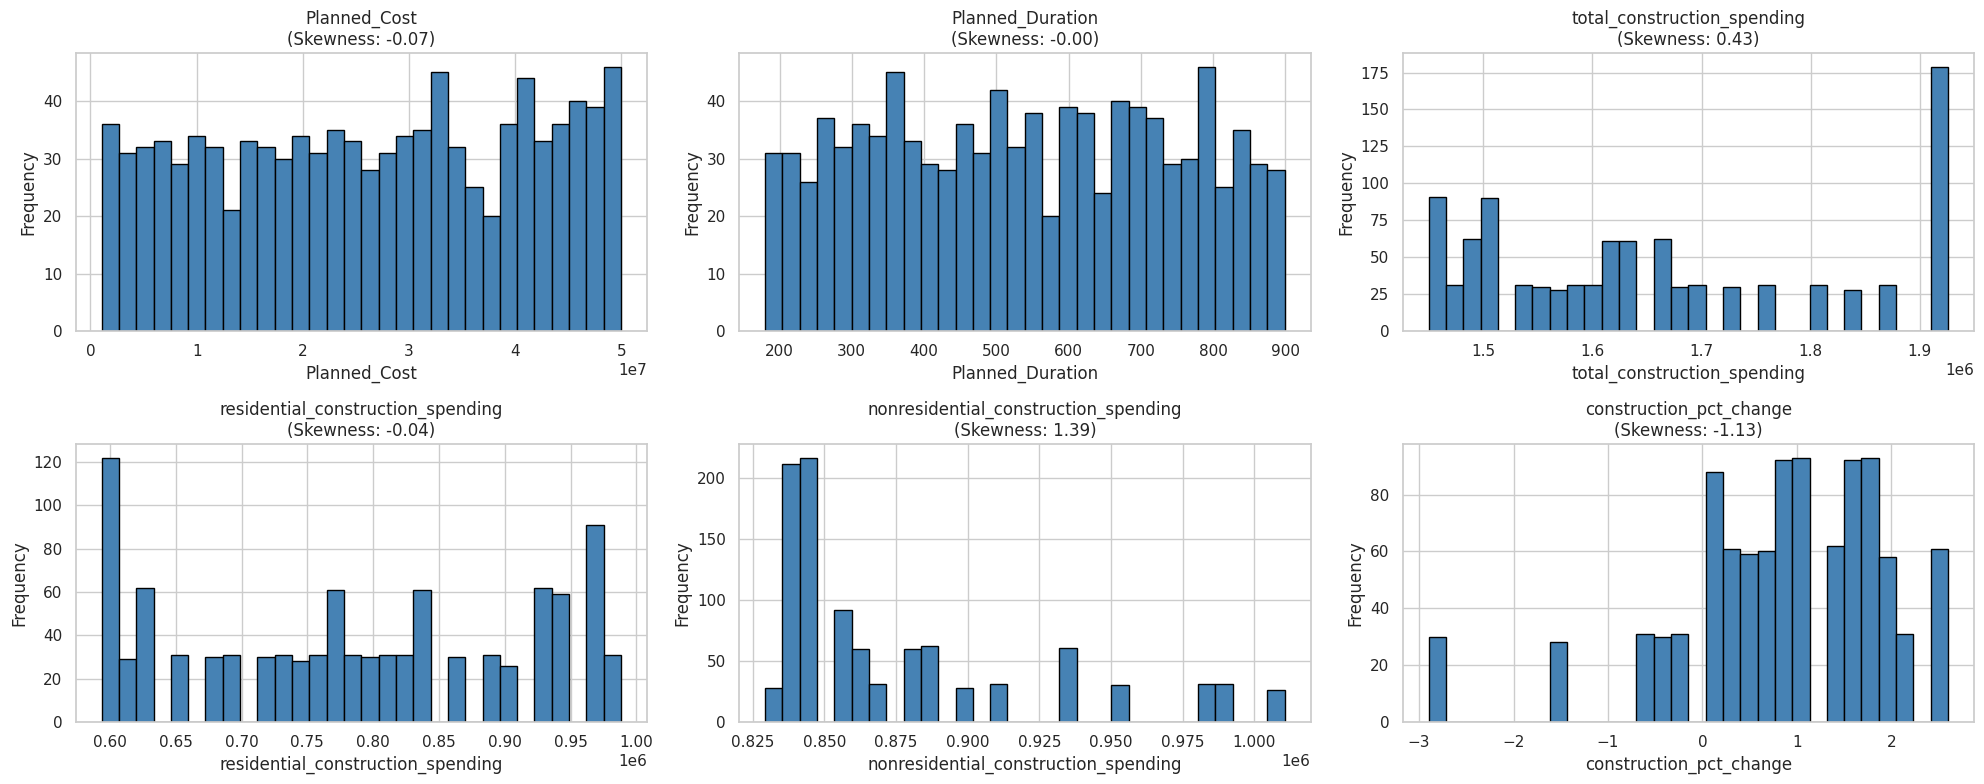

In [39]:
# Visualize the distributions
print("=== NUMERICAL DISTRIBUTION ANALYSIS ===\n")

# Identify numerical columns to inspect
numerical_cols = [
    'Planned_Cost',
    'Planned_Duration',
    'total_construction_spending',
    'residential_construction_spending',
    'nonresidential_construction_spending',
    'construction_pct_change'
]

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df_master[col], bins=30, edgecolor='black', color='steelblue')
    axes[idx].set_title(f'{col}\n(Skewness: {df_master[col].skew():.2f})')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')



plt.tight_layout()
plt.show()

This inspection revealed several important characteristics.

•	Planned_Cost was observed to exhibit a distribution consistent with natural variation in project sizes, with values ranging across a broad spectrum.

•	Planned_duration similarly showed a reasonable distribution across the project sample.

•	The economic indicators, including total_construction_spending, residential_construction_spending, nonresidential_construction_spending, and construction_pct_change showed consistent distributions.


Skewness Check

In [105]:
# Skewness analysis
print("=== SKEWNESS ANALYSIS ===\n")

skewness_report = df_master[numerical_cols].apply(lambda x: x.skew()).reset_index()
skewness_report.columns = ['Feature', 'Skewness']
skewness_report['Skewness_Type'] = skewness_report['Skewness'].apply(
    lambda x: 'High' if abs(x) > 1.5 else 'Moderate' if abs(x) > 0.5 else 'Low'
)
skewness_report['Recommendation'] = skewness_report['Skewness_Type'].apply(
    lambda x: 'Log transform' if x == 'High' else 'Standard scaling' if x == 'Moderate' else 'No transform'
)

print(skewness_report)

=== SKEWNESS ANALYSIS ===

                                Feature  Skewness Skewness_Type  \
0                          Planned_Cost -0.069686           Low   
1                      Planned_Duration -0.001317           Low   
2           total_construction_spending  0.433385           Low   
3     residential_construction_spending -0.036177           Low   
4  nonresidential_construction_spending  1.386947      Moderate   
5               construction_pct_change -1.127453      Moderate   

     Recommendation  
0      No transform  
1      No transform  
2      No transform  
3      No transform  
4  Standard scaling  
5  Standard scaling  


In [106]:
# Actions taken after skewness analysis

print("=== REVERTING LOG TRANSFORMATION ===\n")

# Check if Planned_Cost_log was previously created
if 'Planned_Cost_log' in df_master.columns:
    df_master = df_master.drop(columns=['Planned_Cost_log'])
    print("Removed Planned_Cost_log column (reverting earlier decision)")
    print(f"   Rationale: Skewness analysis shows Planned_Cost has skewness = -0.07 (LOW)")
    print(f"   Log transformation is not needed for low-skew features")
else:
    print("Planned_Cost_log already absent — no action needed")

print(f"\nCurrent columns: {df_master.columns.tolist()}")

=== REVERTING LOG TRANSFORMATION ===

Planned_Cost_log already absent — no action needed

Current columns: ['Project_ID', 'Project_Type', 'Location', 'Start_Date', 'Planned_Cost', 'Planned_Duration', 'Project_Month', 'total_construction_spending', 'residential_construction_spending', 'nonresidential_construction_spending', 'construction_pct_change', 'Cost_Overrun_Pct', 'Cost_Overrun_Binary']


Based on this analysis, the decision was made not to apply any distributional transformations to the numerical features. The rationale for this decision is twofold.

•	First, the observed skewness values do not exceed thresholds at which transformations are not required.

•	Second, retaining the original numerical values supports interpretability, where transformed values would complicate the communication of results to stakeholders.


Outlier Detection

In [107]:
# Detect the outliers
print("=== OUTLIER DETECTION (DIAGNOSTIC ONLY) ===\n")

# Use IQR method for outlier detection
def detect_outliers_iqr(series, k=1.5):
    """Detect outliers using the IQR method."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

# Diagnose outliers for key numerical features
features_to_check = ['Planned_Cost', 'Planned_Duration']

for col in features_to_check:
    outliers, lower, upper = detect_outliers_iqr(df_master[col])
    pct_outliers = len(outliers) / len(df_master) * 100
    print(f"{col}:")
    print(f"  Range: [{df_master[col].min():.2f}, {df_master[col].max():.2f}]")
    print(f"  IQR bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers: {len(outliers)} ({pct_outliers:.1f}%)")
    print()

# Decision: Document outliers but retain them
print("Outliers documented. Retained in dataset (model-stage handling).")

=== OUTLIER DETECTION (DIAGNOSTIC ONLY) ===

Planned_Cost:
  Range: [1045475.00, 49968538.00]
  IQR bounds: [-23580107.38, 77460533.62]
  Outliers: 0 (0.0%)

Planned_Duration:
  Range: [180.00, 899.00]
  IQR bounds: [-167.00, 1241.00]
  Outliers: 0 (0.0%)

Outliers documented. Retained in dataset (model-stage handling).


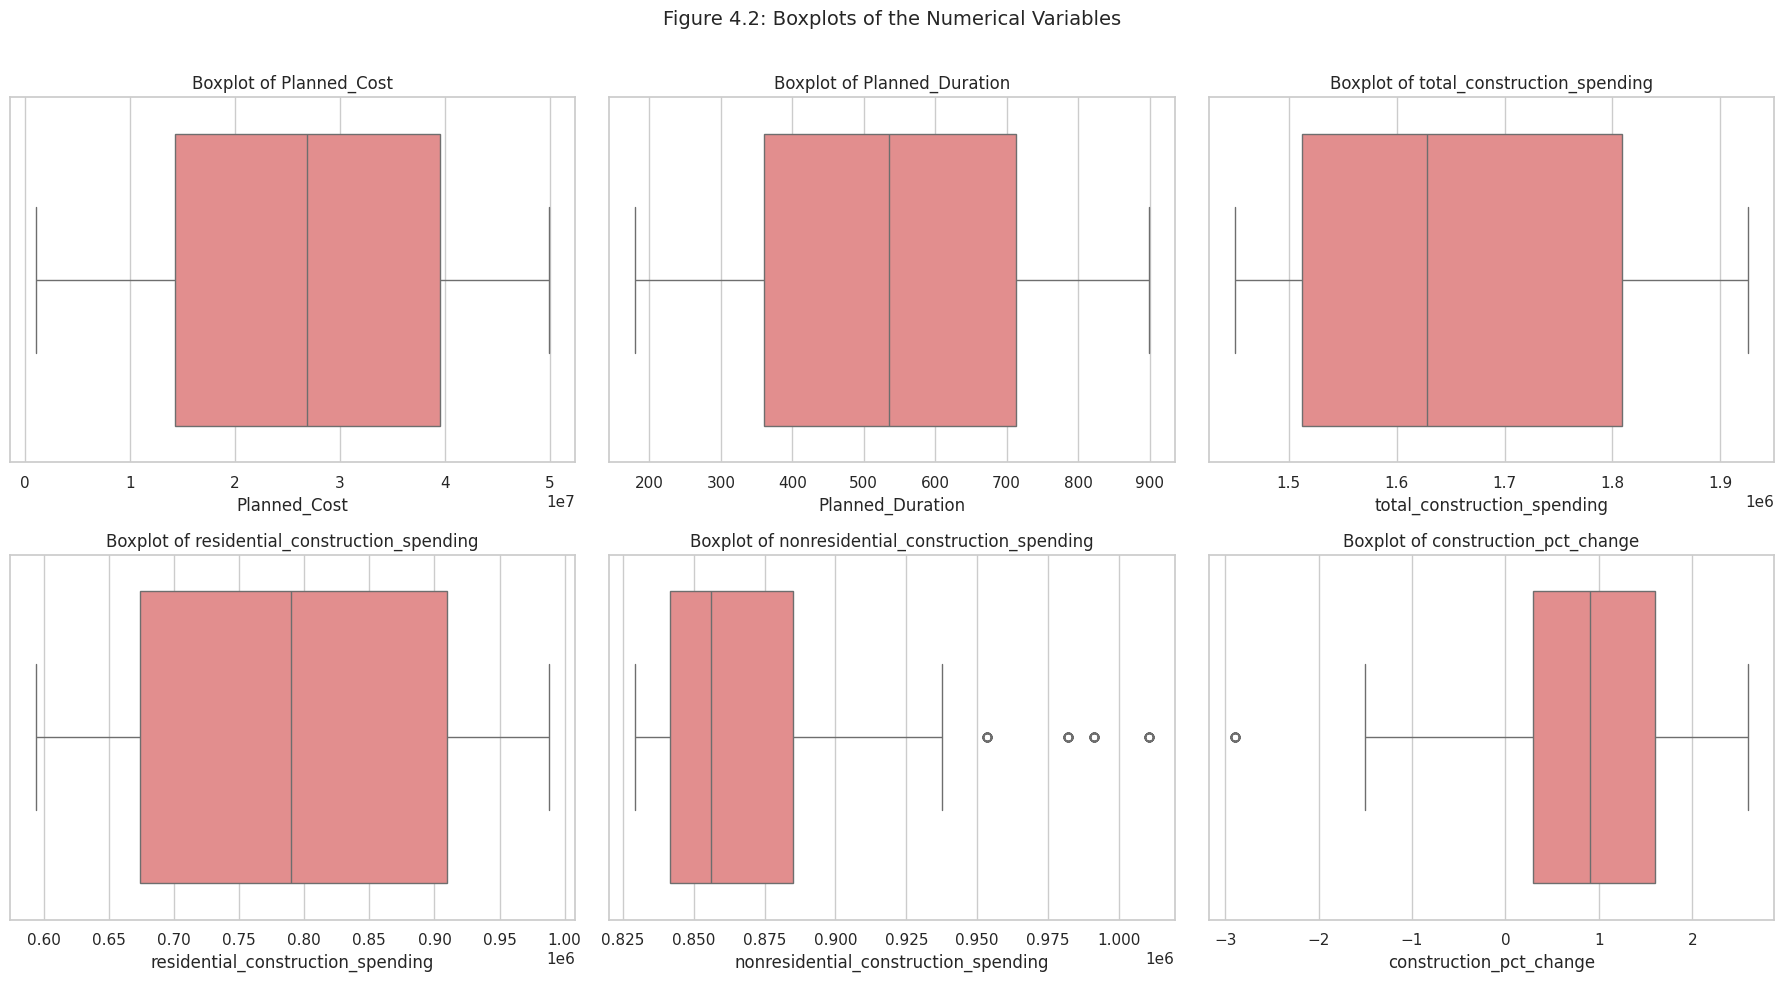

In [43]:
# Visualize the outlier detection

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x=df_master[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col}", fontsize=12)
    axes[i].set_xlabel(col)

# Remove any unused subplot
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Figure 4.2: Boxplots of the Numerical Variables", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{FIG_DIR}/figure_4_2_boxplots.png", dpi=300)
plt.show()

The IQR analysis identified a small number of potential outliers in features such as Planned_Cost and Planned_Duration. The outliers were retained to reduce the generalizability of the resulting model and could distort the ditribution of the data.

#### **3.2 Bivariate Analysis**

##### Numerical Features vs Target

=== NUMERICAL FEATURES: MEAN BY TARGET CLASS ===
                     Planned_Cost  Planned_Duration  \
Cost_Overrun_Binary                                   
0                     27394637.32            547.05   
1                     26222927.16            536.97   

                     total_construction_spending  \
Cost_Overrun_Binary                                
0                                     1666355.97   
1                                     1661896.60   

                     residential_construction_spending  \
Cost_Overrun_Binary                                      
0                                            788048.94   
1                                            786540.19   

                     nonresidential_construction_spending  \
Cost_Overrun_Binary                                         
0                                               878307.16   
1                                               875356.57   

                     construction_pct_chang

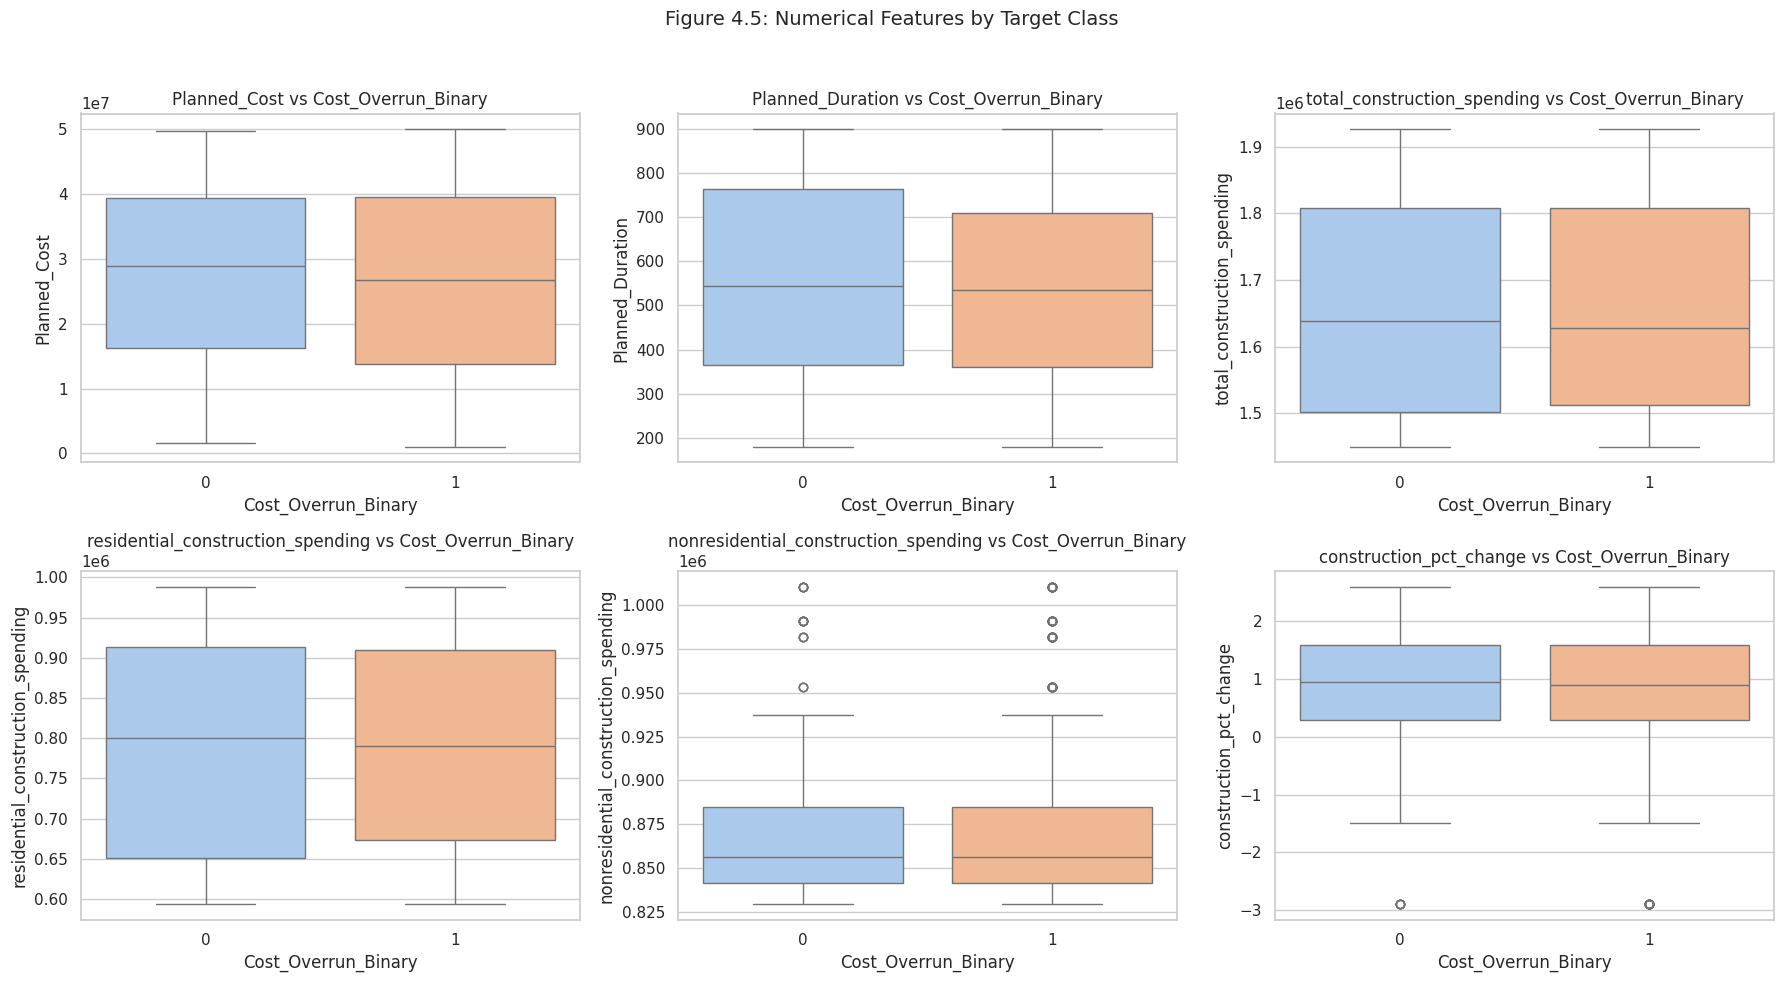

In [44]:
# Numerical grouped summary
numerical_grouped = df_master.groupby(TARGET)[numerical_features].mean().round(2)
print("=== NUMERICAL FEATURES: MEAN BY TARGET CLASS ===")
print(numerical_grouped)

numerical_grouped.to_csv(f"{FIG_DIR}/table_numerical_vs_target.csv")

# Grouped boxplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x=TARGET, y=col, data=df_master, ax=axes[i], palette="pastel")
    axes[i].set_title(f"{col} vs Cost_Overrun_Binary", fontsize=12)
    axes[i].set_xlabel("Cost_Overrun_Binary")

for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Figure 4.5: Numerical Features by Target Class", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{FIG_DIR}/figure_4_5_numerical_vs_target.png", dpi=300)
plt.show()

The bivariate analysis indicates that the mean values of both project-level characteristics and macroeconomic indicators are relatively similar across the two target classes. These observations provide an initial understanding of the dataset and support the modelling process.

##### Categorical Feature Vs Target

=== BIVARIATE ANALYSIS: Project_Type vs Cost_Overrun_Binary ===
              No Overrun (%)  Overrun (%)
Project_Type                             
Bridge                 13.33        86.67
Building               19.47        80.53
Dam                    17.16        82.84
Road                   18.42        81.58
Tunnel                 14.08        85.92


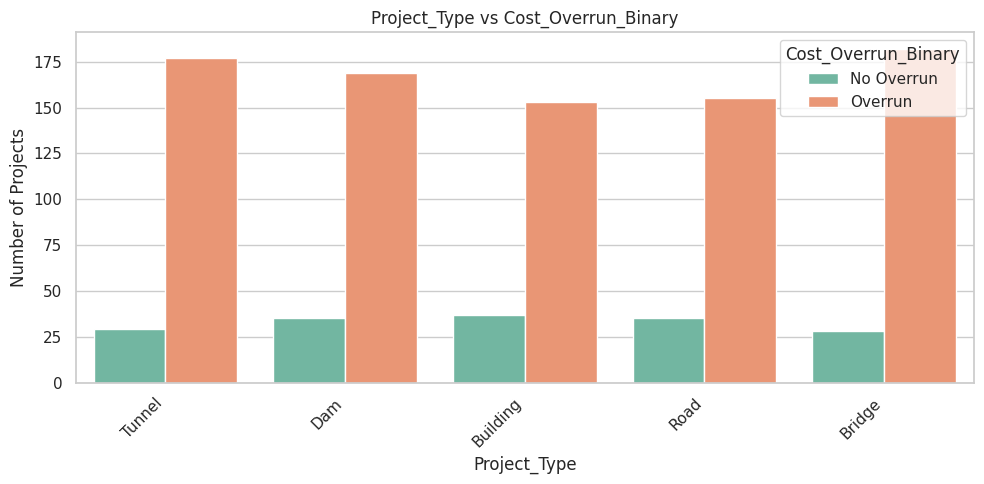

=== BIVARIATE ANALYSIS: Location vs Cost_Overrun_Binary ===
             No Overrun (%)  Overrun (%)
Location                                
Chicago               17.46        82.54
Houston               13.16        86.84
Los Angeles           18.96        81.04
New York              16.10        83.90
Seattle               16.10        83.90


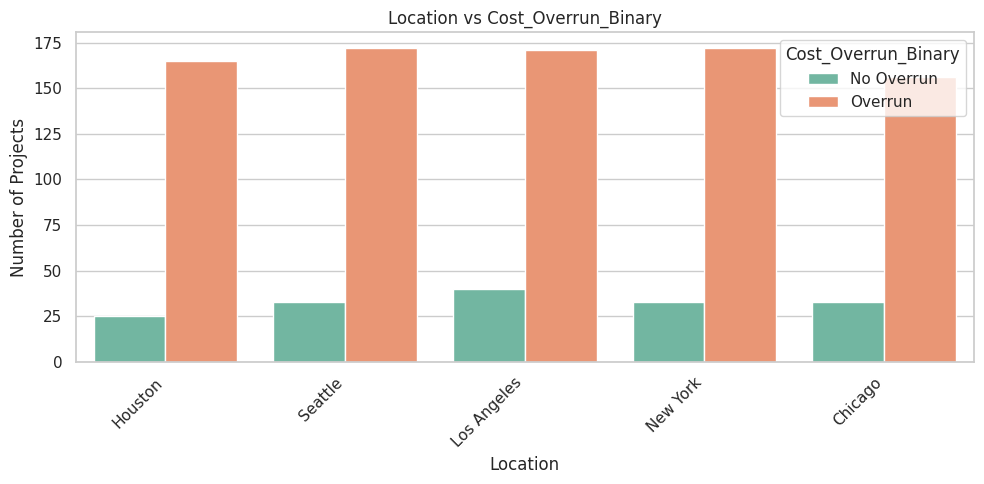

In [108]:
def bivariate_categorical_analysis(df, feature, target, filename_suffix):
    print(f"=== BIVARIATE ANALYSIS: {feature} vs {target} ===")

    # Cross-tabulation with percentages
    ct = pd.crosstab(df[feature], df[target], normalize="index") * 100
    ct = ct.round(2)
    ct.columns = ["No Overrun (%)", "Overrun (%)"]
    print(ct)

    # Save the crosstab
    ct.to_csv(f"{FIG_DIR}/table_bivariate_{filename_suffix}.csv")

    # Countplot showing counts of Overrun/No Overrun per category
    plt.figure(figsize=(10, 5))
    sns.countplot(x=feature, hue=target, data=df, palette="Set2")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{feature} vs {target}")
    plt.xlabel(feature)
    plt.ylabel("Number of Projects")
    plt.legend(title="Cost_Overrun_Binary", labels=["No Overrun", "Overrun"])

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/figure_bivariate_{filename_suffix}.png", dpi=300)
    plt.show()

bivariate_categorical_analysis(df_master, "Project_Type", TARGET, "project_type")
bivariate_categorical_analysis(df_master, "Location", TARGET, "location")

#### **3.3.Correlation Heatmap**

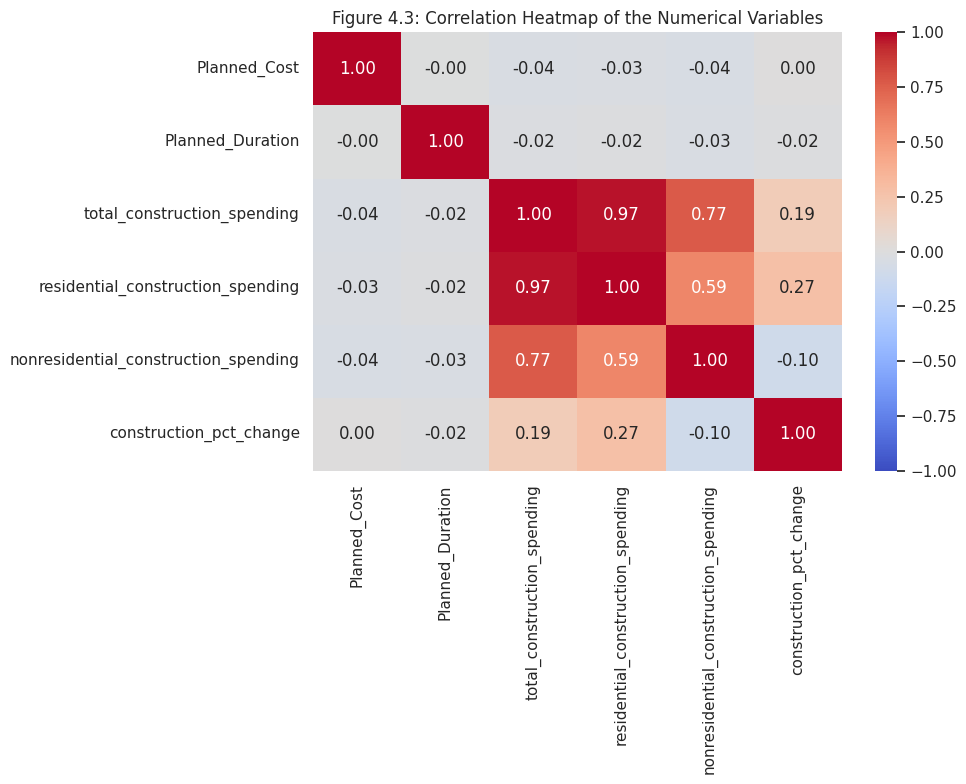

In [46]:
# correlation Analysis
plt.figure(figsize=(10, 8))
corr_matrix = df_master[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Figure 4.3: Correlation Heatmap of the Numerical Variables")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/figure_4_3_correlation_heatmap.png", dpi=300)
plt.show()

#### **3.4.Class Distribution of Target**

In [109]:
# Target Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET, data=df_master, palette="Set2")
plt.title("Figure 4.4: Class Distribution of Cost_Overrun_Binary")
plt.xlabel("Cost Overrun (0 = No, 1 = Yes)")
plt.ylabel("Number of Projects")

plt.savefig(f"{FIG_DIR}/figure_4_4_class_distribution.png", dpi=300)
plt.close()

# Also produce the summary table for Chapter 4
class_distribution = df_master[TARGET].value_counts().reset_index()
class_distribution.columns = ["Cost_Overrun_Binary", "Count"]
class_distribution["Proportion (%)"] = (
    class_distribution["Count"] / len(df_master) * 100
).round(2)

class_distribution.to_csv(f"{FIG_DIR}/table_class_distribution.csv", index=False)
print("=== TARGET CLASS DISTRIBUTION ===")
print(class_distribution)

=== TARGET CLASS DISTRIBUTION ===
   Cost_Overrun_Binary  Count  Proportion (%)
0                    1    836            83.6
1                    0    164            16.4


=== CLASS DISTRIBUTION VISUALIZATION ===



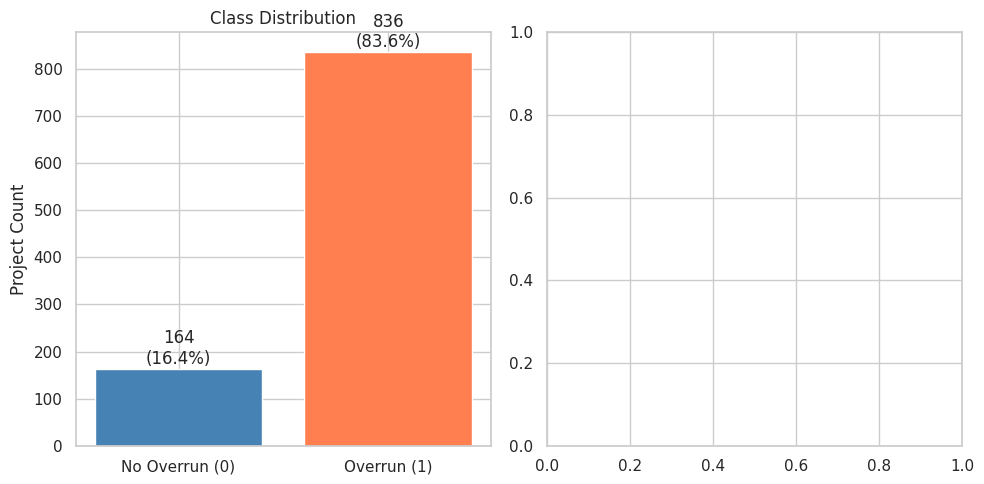

In [48]:
# Visualize Class Distribution
import matplotlib.pyplot as plt

print("=== CLASS DISTRIBUTION VISUALIZATION ===\n")

# Counts and percentages
class_counts = df_master['Cost_Overrun_Binary'].value_counts()
class_pct = (class_counts / len(df_master)) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Bar chart
axes[0].bar(
    ['No Overrun (0)', 'Overrun (1)'],
    [class_counts[0], class_counts[1]],
    color=['steelblue', 'coral']
)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Project Count')

# Annotate
for i, v in enumerate([class_counts[0], class_counts[1]]):
    axes[0].text(i, v + 10, f"{v}\n({class_pct[i]:.1f}%)", ha='center')

plt.tight_layout()
plt.show()

Observed Imbalance: 83.6% Overrun vs 16.4% No Overrun (~5:1 ratio)

Strategy:

1.	Class Weights: Use class_weight='balanced' in all ML algorithms to weight the minority class more heavily during training.
2.	Stratified Sampling: Apply stratified train-validation-test splits to preserve class proportions across subsets.
3.	Robust Metrics: Use AUC-ROC as the primary evaluation metric (robust to imbalance), supported by Precision, Recall, F1-Score, and Confusion Matrix analysis.

Advantages:

  •	Avoids synthetic data generation (consistent with original proposal scope)

  •	Algorithm-agnostic; supported by Scikit-learn, XGBoost, LightGBM, CatBoost

  •	Standard practice in construction cost overrun research (Hamdan et al., 2025)
  
  •	Preserves dataset integrity and reproducibility
Reporting, both raw and class-balanced model performances will be reported in the dissertation for transparency.


#### **Step 4: Feature Engineering**

###### Dervie New Features

In [110]:
# Derive new features
import numpy as np
import pandas as pd

print("=== DERIVED FEATURE CREATION ===\n")

# 1. Cost per Day (project intensity)
df_master['Cost_per_Day'] = df_master['Planned_Cost'] / df_master['Planned_Duration']

# 2. Duration Category
df_master['Duration_Category'] = pd.cut(
    df_master['Planned_Duration'],
    bins=[0, 300, 600, 1000],
    labels=['Short', 'Medium', 'Long']
)

# 3. Log Transformation
df_master['Planned_Cost_log'] = np.log1p(df_master['Planned_Cost'])

print("Derived features created:")
print(['Cost_per_Day', 'Duration_Category', 'Planned_Cost_log'])

=== DERIVED FEATURE CREATION ===

Derived features created:
['Cost_per_Day', 'Duration_Category', 'Planned_Cost_log']


##### Multi-Collinearity Check

=== MULTICOLLINEARITY ANALYSIS (CORRELATION MATRIX) ===



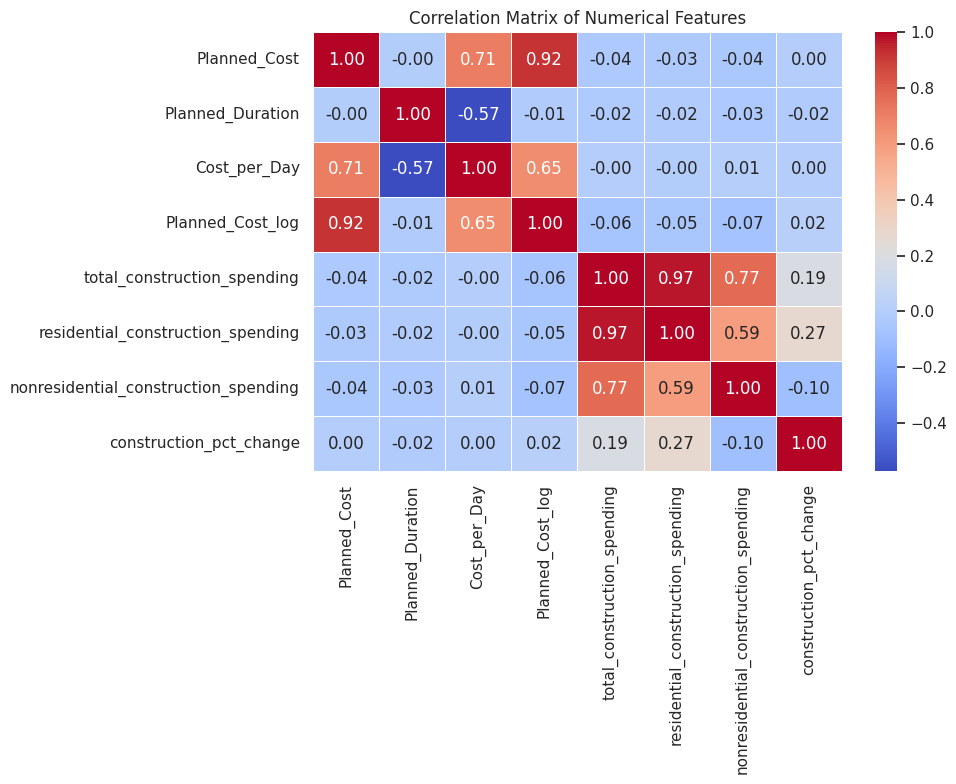

In [111]:
# Correlation Check

import seaborn as sns
import matplotlib.pyplot as plt

print("=== MULTICOLLINEARITY ANALYSIS (CORRELATION MATRIX) ===\n")

# Select numerical features (Tier 1 + Tier 2 + derived)
numerical_features = [
    'Planned_Cost',
    'Planned_Duration',
    'Cost_per_Day',
    'Planned_Cost_log',
    'total_construction_spending',
    'residential_construction_spending',
    'nonresidential_construction_spending',
    'construction_pct_change'
]

# Compute correlation matrix
corr_matrix = df_master[numerical_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

##### Observation:

All the features were retained, as multicollinearity was considered acceptable because the variables represent different sectors.They represent the meaningful economic variables and the models used are robust to multicollinearity.

##### Feature Set Preparation

In [112]:
RANDOM_STATE = 42
TARGET = "Cost_Overrun_Binary"

tier1_features = [
    'Project_Type',
    'Location',
    'Planned_Cost',
    'Planned_Duration',
    'Cost_per_Day',
    'Planned_Cost_log'
]

tier2_features = [
    'total_construction_spending',
    'residential_construction_spending',
    'nonresidential_construction_spending',
    'construction_pct_change'
]

categorical_cols = ["Project_Type", "Location", "Duration_Category"]
numerical_cols_A = ["Planned_Cost", "Planned_Duration", "Cost_per_Day", "Planned_Cost_log"]
numerical_cols_B = numerical_cols_A + tier2_features

y = df_master[TARGET]

X_A = df_master[tier1_features + ['Duration_Category']]
X_B = df_master[tier1_features + tier2_features + ['Duration_Category']]

##### Perform the train/validation/test split

In [113]:
from sklearn.model_selection import train_test_split
# 70% train, 15% validation, 15% test using stratified sampling

# Model A
X_A_train, X_A_temp, y_train, y_temp = train_test_split(
    X_A, y, test_size=0.30, stratify=y, random_state=42
)
X_A_val, X_A_test, y_val, y_test = train_test_split(
    X_A_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Model B (same y splits reused)
X_B_train, X_B_temp, _, _ = train_test_split(
    X_B, y, test_size=0.30, stratify=y, random_state=42
)
X_B_val, X_B_test, _, _ = train_test_split(
    X_B_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

Encoding and Scaling

In [114]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [115]:
# Model A preprocessor
preprocessor_A = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols_A)
    ]
)

# Model B preprocessor
preprocessor_B = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols_B)
    ]
)

###### Fit Encoding and Scaling on the training set only

In [116]:
# Fit on training set only
preprocessor_A.fit(X_A_train)
preprocessor_B.fit(X_B_train)

# Transform all subsets
X_A_train_processed = preprocessor_A.transform(X_A_train)
X_A_val_processed = preprocessor_A.transform(X_A_val)
X_A_test_processed = preprocessor_A.transform(X_A_test)

X_B_train_processed = preprocessor_B.transform(X_B_train)
X_B_val_processed = preprocessor_B.transform(X_B_val)
X_B_test_processed = preprocessor_B.transform(X_B_test)

In [117]:
# Verify shapes
print(f"X_A train shape: {X_A_train_processed.shape}")
print(f"X_A val shape:   {X_A_val_processed.shape}")
print(f"X_A test shape:  {X_A_test_processed.shape}")

print(f"X_B train shape: {X_B_train_processed.shape}")
print(f"X_B val shape:   {X_B_val_processed.shape}")
print(f"X_B test shape:  {X_B_test_processed.shape}")

X_A train shape: (700, 17)
X_A val shape:   (150, 17)
X_A test shape:  (150, 17)
X_B train shape: (700, 21)
X_B val shape:   (150, 21)
X_B test shape:  (150, 21)


The dataset is transformed into a structured and modelling-ready format. The feature engineering approach balances simplicity, interpretability and predictive capability, making sure that the resulting models remain aligned with the research objectives.

#### **Step 5: Model Building**

##### 1. Import necessary libraries

In [118]:
!pip install catboost

In [119]:
# Import the required libraries
import joblib
import shap

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier



##### 2. Baseline Model Initialization

In [120]:
def get_baseline_models():
    return {
        "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
        "LightGBM": LGBMClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        "CatBoost": CatBoostClassifier(auto_class_weights="Balanced", verbose=0, random_state=RANDOM_STATE)
    }

baseline_models_A = get_baseline_models()
baseline_models_B = get_baseline_models()


##### 3. Model Training Function

In [121]:
def evaluate_models(models, X_train, X_eval, y_train, y_eval):
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_eval)
        y_proba = model.predict_proba(X_eval)[:, 1]

        results[name] = {
            "model": model,
            "auc_roc": roc_auc_score(y_eval, y_proba),
            "accuracy": accuracy_score(y_eval, y_pred),
            "precision": precision_score(y_eval, y_pred),
            "recall": recall_score(y_eval, y_pred),
            "f1": f1_score(y_eval, y_pred),
            "confusion_matrix": confusion_matrix(y_eval, y_pred),
            "y_pred": y_pred,
            "y_proba": y_proba
        }
    return results

##### 4.Baseline Evaluation on Validation Set


In [122]:
results_baseline_val_A = evaluate_models(
    baseline_models_A, X_A_train_processed, X_A_val_processed, y_train, y_val
)

results_baseline_val_B = evaluate_models(
    baseline_models_B, X_B_train_processed, X_B_val_processed, y_train, y_val
)


[LightGBM] [Info] Number of positive: 585, number of negative: 115
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [123]:
# Function to create Metric Summary
def summarize_results(results, subset_label, config_label, tuning_label):
    rows = []
    for algo_name, r in results.items():
        rows.append({
            "Model": config_label,
            "Version": tuning_label,
            "Subset": subset_label,
            "Algorithm": algo_name,
            "AUC-ROC": r["auc_roc"],
            "Accuracy": r["accuracy"],
            "Precision": r["precision"],
            "Recall": r["recall"],
            "F1": r["f1"]
        })
    return pd.DataFrame(rows)

In [124]:
# Consolidation of Baseline Model results

baseline_results = {
    "Model A": {
        "Baseline": {
            "Validation": results_baseline_val_A
        },
    },
    "Model B": {
        "Baseline": {
            "Validation": results_baseline_val_B,
        }

    }
}

In [125]:
summary_A_baseline_val = summarize_results(results_baseline_val_A, "Validation", "Model A", "Baseline")
summary_B_baseline_val = summarize_results(results_baseline_val_B, "Validation", "Model B", "Baseline")
metrics_summary_baseline = pd.concat([
    summary_A_baseline_val,
    summary_B_baseline_val
], ignore_index=True)

In [126]:
metrics_summary_baseline

,Model,Version,Subset,Algorithm,AUC-ROC,Accuracy,Precision,Recall,F1
0,Model A,Baseline,Validation,Logistic Regression,0.536045,0.566667,0.867470,0.571429,0.688995
1,Model A,Baseline,Validation,Random Forest,0.539848,0.820000,0.836735,0.976190,0.901099
2,Model A,Baseline,Validation,XGBoost,0.571098,0.780000,0.844444,0.904762,0.873563
3,Model A,Baseline,Validation,LightGBM,0.539352,0.726667,0.845528,0.825397,0.835341
4,Model A,Baseline,Validation,CatBoost,0.561839,0.713333,0.842975,0.809524,0.825911
5,Model B,Baseline,Validation,Logistic Regression,0.535714,0.540000,0.870130,0.531746,0.660099
6,Model B,Baseline,Validation,Random Forest,0.530589,0.833333,0.838926,0.992063,0.909091
7,Model B,Baseline,Validation,XGBoost,0.555886,0.813333,0.845070,0.952381,0.895522
8,Model B,Baseline,Validation,LightGBM,0.558532,0.746667,0.849206,0.849206,0.849206
9,Model B,Baseline,Validation,CatBoost,0.526455,0.780000,0.844444,0.904762,0.873563


Interpretation of Results:

- Model A, with Tier 1 features produces the highest baseline AUC-ROC value with XGBoost (0.5711)
- There is a consistent pattern observed across all baseline models highlights limitations of the default parameter configurations for this classification task.
 - So , hyperparameter tuning is applied on all the five algorithms to determine whether adjustments to key parameters can improve discriminative performance.



##### **Step 6: Hyperparameter Tuning for All Five Algorithms**

In [129]:
# Hyperparameter grid definitions

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l2"]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 400],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 400],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 6, 10],
        "subsample": [0.8, 1.0]
    },
    "LightGBM": {
        "n_estimators": [100, 200, 400],
        "learning_rate": [0.05, 0.1],
        "max_depth": [-1, 6, 10],
        "num_leaves": [31, 63, 127]
    },
    "CatBoost": {
        "iterations": [200, 400],
        "depth": [4, 6, 8],
        "learning_rate": [0.05, 0.1]
    }
}

def tune_models(models, param_grids, X_train, y_train):
    tuned = {}
    for name, model in models.items():
        search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        tuned[name] = search.best_estimator_
    return tuned

In [128]:
# Run tuning for both configurations
tuned_models_A = tune_models(get_baseline_models(), param_grids, X_A_train_processed, y_train)
tuned_models_B = tune_models(get_baseline_models(), param_grids, X_B_train_processed, y_train)

[LightGBM] [Info] Number of positive: 585, number of negative: 115
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

##### Evaluate Tuned models on Validation Subset

In [130]:
results_tuned_val_A = evaluate_models(tuned_models_A, X_A_train_processed, X_A_val_processed, y_train, y_val)
results_tuned_val_B = evaluate_models(tuned_models_B, X_B_train_processed, X_B_val_processed, y_train, y_val)



[LightGBM] [Info] Number of positive: 585, number of negative: 115
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [131]:
# Consolidation of Tuned Model results

tuned_results = {
    "Model A": {
        "Tuned": {
            "Validation": results_tuned_val_A
        },
    },
    "Model B": {
        "Tuned": {
            "Validation": results_tuned_val_B,
        }

    }
}
summary_A_tuned_val = summarize_results(results_tuned_val_A, "Validation", "Model A", "Tuned")
summary_B_tuned_val = summarize_results(results_tuned_val_B, "Validation", "Model B", "Tuned")
metrics_summary_tuned = pd.concat([
    summary_A_tuned_val,
    summary_B_tuned_val
], ignore_index=True)

In [132]:
metrics_summary_tuned

,Model,Version,Subset,Algorithm,AUC-ROC,Accuracy,Precision,Recall,F1
0,Model A,Tuned,Validation,Logistic Regression,0.538690,0.560000,0.875000,0.555556,0.679612
1,Model A,Tuned,Validation,Random Forest,0.547288,0.806667,0.834483,0.960317,0.892989
2,Model A,Tuned,Validation,XGBoost,0.521164,0.820000,0.836735,0.976190,0.901099
3,Model A,Tuned,Validation,LightGBM,0.568122,0.713333,0.854701,0.793651,0.823045
4,Model A,Tuned,Validation,CatBoost,0.575066,0.700000,0.858407,0.769841,0.811715
5,Model B,Tuned,Validation,Logistic Regression,0.535384,0.546667,0.871795,0.539683,0.666667
6,Model B,Tuned,Validation,Random Forest,0.523313,0.833333,0.838926,0.992063,0.909091
7,Model B,Tuned,Validation,XGBoost,0.553571,0.800000,0.838028,0.944444,0.888060
8,Model B,Tuned,Validation,LightGBM,0.535384,0.746667,0.849206,0.849206,0.849206
9,Model B,Tuned,Validation,CatBoost,0.556548,0.760000,0.826087,0.904762,0.863636


#### **Step 7: Final Model Evaluation**

##### 7.1 Comparison of Results

In [133]:
# Generate the summary table- Baseline vs Tuned Results
summary_A_baseline_val = summarize_results(results_baseline_val_A, "Validation", "Model A", "Baseline")
summary_A_tuned_val = summarize_results(results_tuned_val_A, "Validation", "Model A", "Tuned")

summary_B_baseline_val = summarize_results(results_baseline_val_B, "Validation", "Model B", "Baseline")
summary_B_tuned_val = summarize_results(results_tuned_val_B, "Validation", "Model B", "Tuned")

metrics_summary = pd.concat([
    summary_A_baseline_val,summary_B_baseline_val,
    summary_A_tuned_val,
    summary_B_tuned_val
], ignore_index=True)

In [134]:
# Print the Metrics summary table
metrics_summary

,Model,Version,Subset,Algorithm,AUC-ROC,Accuracy,Precision,Recall,F1
0,Model A,Baseline,Validation,Logistic Regression,0.536045,0.566667,0.867470,0.571429,0.688995
1,Model A,Baseline,Validation,Random Forest,0.539848,0.820000,0.836735,0.976190,0.901099
2,Model A,Baseline,Validation,XGBoost,0.571098,0.780000,0.844444,0.904762,0.873563
3,Model A,Baseline,Validation,LightGBM,0.539352,0.726667,0.845528,0.825397,0.835341
4,Model A,Baseline,Validation,CatBoost,0.561839,0.713333,0.842975,0.809524,0.825911
5,Model B,Baseline,Validation,Logistic Regression,0.535714,0.540000,0.870130,0.531746,0.660099
6,Model B,Baseline,Validation,Random Forest,0.530589,0.833333,0.838926,0.992063,0.909091
7,Model B,Baseline,Validation,XGBoost,0.555886,0.813333,0.845070,0.952381,0.895522
8,Model B,Baseline,Validation,LightGBM,0.558532,0.746667,0.849206,0.849206,0.849206
9,Model B,Baseline,Validation,CatBoost,0.526455,0.780000,0.844444,0.904762,0.873563


Interpretation of Results:

The improvement in AUC_ROC after tuning is small but consistent, which indicates that hyperparameter tuning helps refine the model configurations without changing the underlying limitations imposed by the dataset structure.

##### 7.2 Model Selection



- Model Selection must be based on the tuned validation AUC-ROC rather than the baseline validation results or the test set.

- This ensures that the model is chosen on the basis of an optimised configuration

In [135]:
best_algo_A = max(results_tuned_val_A, key=lambda k: results_tuned_val_A[k]["auc_roc"])
best_algo_B = max(results_tuned_val_B, key=lambda k: results_tuned_val_B[k]["auc_roc"])

best_model_A = tuned_models_A[best_algo_A]
best_model_B = tuned_models_B[best_algo_B]

print(f"Selected Model A: {best_algo_A}")
print(f"Validation AUC-ROC: {results_tuned_val_A[best_algo_A]['auc_roc']:.4f}\n")

print(f"Selected Model B: {best_algo_B}")
print(f"Validation AUC-ROC: {results_tuned_val_B[best_algo_B]['auc_roc']:.4f}")


Selected Model A: CatBoost
Validation AUC-ROC: 0.5751

Selected Model B: CatBoost
Validation AUC-ROC: 0.5565


Selected Model:

 - CatBoost achieved the highest AUC-ROC score for both Model A and Model B on the validation subset.
 - CatBoost was selected as the representative model for each configuration and the final test evaluation stage will be performed on this model.


##### 7.3 Final Test Evaluation

In [136]:
# Evaluation on Test sets
final_test_A = evaluate_models(
    {best_algo_A: best_model_A},
    X_A_train_processed, X_A_test_processed, y_train, y_test
)

final_test_B = evaluate_models(
    {best_algo_B: best_model_B},
    X_B_train_processed, X_B_test_processed, y_train, y_test
)

In [137]:
# Consolidation of Tuned Model results

test_results = {
    "Model A": {
        "Final": {
            "Test": final_test_A
        },
    },
    "Model B": {
        "Final": {
            "Test": final_test_B,
        }

    }
}

summary_A_test = summarize_results(final_test_A, "Test", "Model A", "Final")
summary_B_test = summarize_results(final_test_B, "Test", "Model B", "Final")
metrics_summary_test = pd.concat([
    summary_A_test,
    summary_B_test
], ignore_index=True)

In [138]:
metrics_summary_test

,Model,Version,Subset,Algorithm,AUC-ROC,Accuracy,Precision,Recall,F1
0,Model A,Final,Test,CatBoost,0.4032,0.673333,0.822034,0.776,0.798354
1,Model B,Final,Test,CatBoost,0.4656,0.780000,0.838235,0.912,0.873563


In [139]:
# Save Trained Models
import joblib

def save_model(model, filename):
    path = os.path.join(MODEL_DIR, filename)
    joblib.dump(model, path)
    print(f"Saved: {path}")

# Save selected best-performing models
save_model(best_model_A, "best_model_A.pkl")
save_model(best_model_B, "best_model_B.pkl")

# Optional: save all tuned models
for name, model in tuned_models_A.items():
    save_model(model, f"tuned_modelA_{name.replace(' ', '_')}.pkl")

for name, model in tuned_models_B.items():
    save_model(model, f"tuned_modelB_{name.replace(' ', '_')}.pkl")

Saved: /content/drive/MyDrive/CostOverrunPrediction/models/best_model_A.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/best_model_B.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelA_Logistic_Regression.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelA_Random_Forest.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelA_XGBoost.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelA_LightGBM.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelA_CatBoost.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelB_Logistic_Regression.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelB_Random_Forest.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelB_XGBoost.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/models/tuned_modelB_LightGBM.pkl
Saved: /content/drive/MyDrive/CostOverrunPrediction/m

##### 7.4 ROC Curves

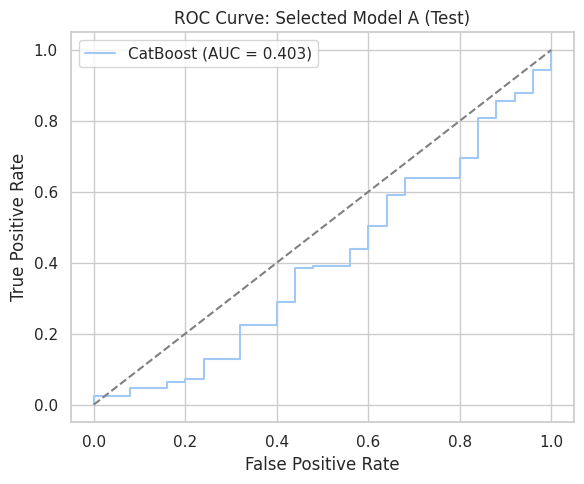

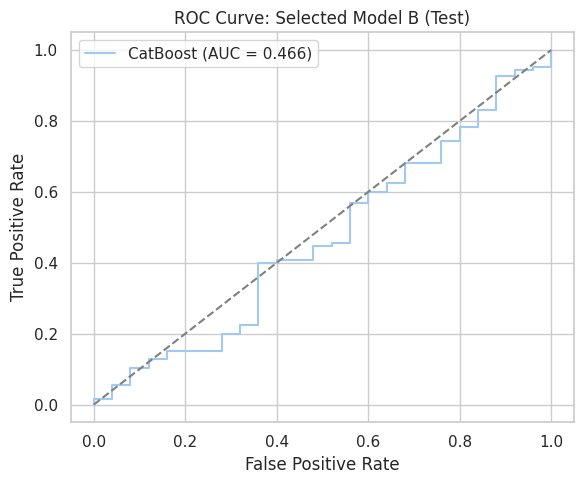

In [140]:
# Plot ROC Curves
def plot_selected_roc(results, y_true, title):
    plt.figure(figsize=(6, 5))
    for name, r in results.items():
        fpr, tpr, _ = roc_curve(y_true, r["y_proba"])
        plt.plot(fpr, tpr, label=f"{name} (AUC = {r['auc_roc']:.3f})")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_selected_roc(final_test_A, y_test, "ROC Curve: Selected Model A (Test)")
plot_selected_roc(final_test_B, y_test, "ROC Curve: Selected Model B (Test)")

Interpretation of the Results:

- This proves that the inclusion of Tier 2 macroeconomic indicators contributes to  a modest improvement in generalization performance.
- The magnitude of the improvement is limited, however consistent with the earlier baseline and tuned validation results.
- This indicates that macroeconomic indictors provides a small but measurable benefit to the predictive framework,

##### 7.5 Confusion Matrices

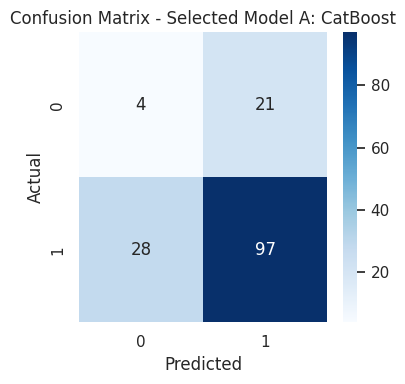

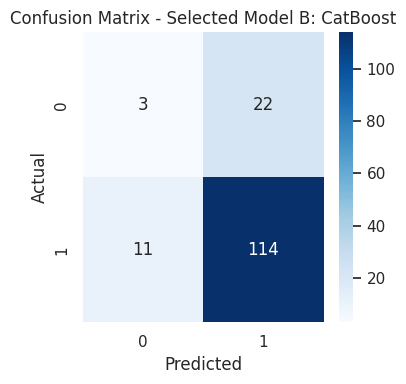

In [141]:
# Confusion Matrix
def plot_selected_cm(results, title_prefix):
    for name, r in results.items():
        plt.figure(figsize=(4, 4))
        sns.heatmap(r["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
        plt.title(f"{title_prefix}: {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

plot_selected_cm(final_test_A, "Confusion Matrix - Selected Model A")
plot_selected_cm(final_test_B, "Confusion Matrix - Selected Model B")

Intepretation:

  - Model B improves classification of the majority class by reducing false negatives (from 28 to 11), producing more true positives with a small change in false positives.

##### 7.6 Comparison of Results

###### Baseline vs Tuned

In [142]:
# Comparison- Baseline Vs Tuned
def compare_baseline_tuned(baseline, tuned, config_label):
    rows = []
    for algo in baseline.keys():
        rows.append({
            "Algorithm": algo,
            "Model": config_label,
            "Baseline AUC": baseline[algo]["auc_roc"],
            "Tuned AUC": tuned[algo]["auc_roc"],
            "Delta AUC": tuned[algo]["auc_roc"] - baseline[algo]["auc_roc"]
        })
    return pd.DataFrame(rows)

baseline_vs_tuned_A = compare_baseline_tuned(results_baseline_val_A, results_tuned_val_A, "Model A")
baseline_vs_tuned_B = compare_baseline_tuned(results_baseline_val_B, results_tuned_val_B, "Model B")

In [143]:
print(baseline_vs_tuned_A)

             Algorithm    Model  Baseline AUC  Tuned AUC  Delta AUC
0  Logistic Regression  Model A      0.536045   0.538690   0.002646
1        Random Forest  Model A      0.539848   0.547288   0.007440
2              XGBoost  Model A      0.571098   0.521164  -0.049934
3             LightGBM  Model A      0.539352   0.568122   0.028770
4             CatBoost  Model A      0.561839   0.575066   0.013228


In [144]:
print(baseline_vs_tuned_B)

             Algorithm    Model  Baseline AUC  Tuned AUC  Delta AUC
0  Logistic Regression  Model B      0.535714   0.535384  -0.000331
1        Random Forest  Model B      0.530589   0.523313  -0.007275
2              XGBoost  Model B      0.555886   0.553571  -0.002315
3             LightGBM  Model B      0.558532   0.535384  -0.023148
4             CatBoost  Model B      0.526455   0.556548   0.030093


###### Model A vs Model B Comparison

In [145]:
def compare_A_B(results_A, results_B):
    rows = []
    for algo in results_A.keys():
        rows.append({
            "Algorithm": algo,
            "Model A AUC": results_A[algo]["auc_roc"],
            "Model B AUC": results_B[algo]["auc_roc"],
            "Delta AUC": results_B[algo]["auc_roc"] - results_A[algo]["auc_roc"]
        })
    return pd.DataFrame(rows)

comparison_tuned_val = compare_A_B(results_tuned_val_A, results_tuned_val_B)

In [ ]:
print(comparison_tuned_val)

##### **Step 8: SHAP Implementation**

##### 8.1 SHAP explainers and Values computation

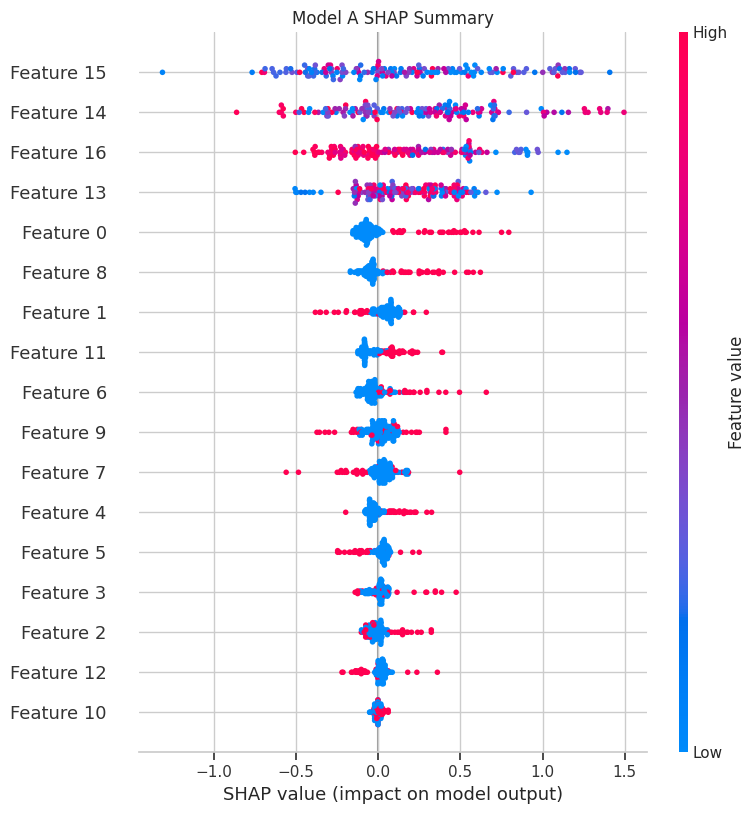

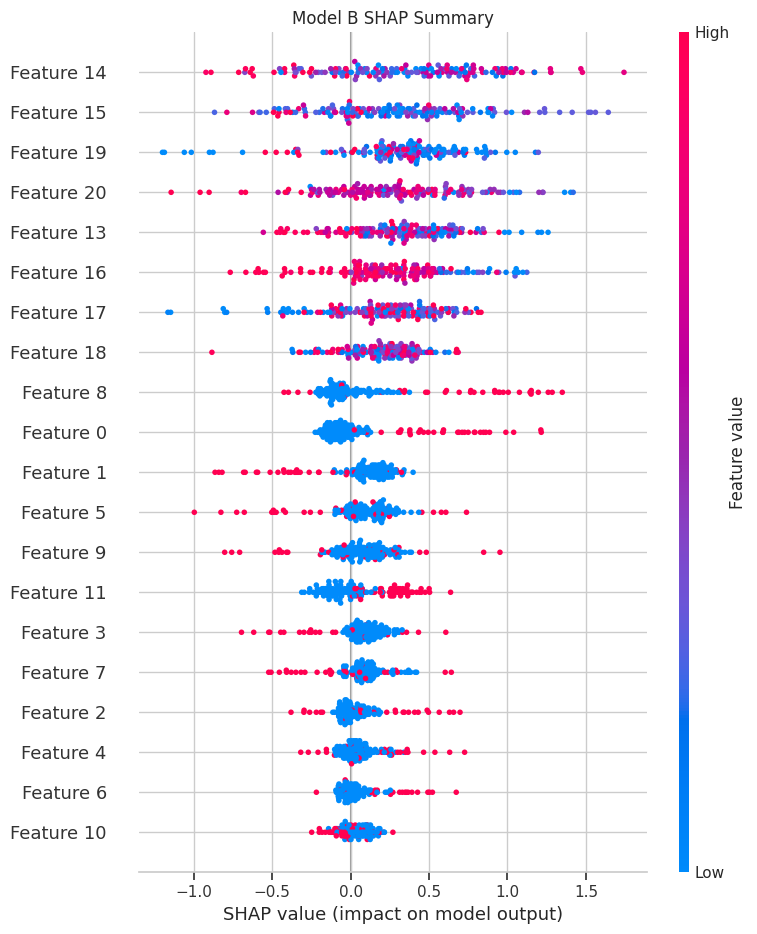

In [146]:
# SHAP Definition
def run_shap(model, X_processed, title_prefix):
    if hasattr(model, "predict_proba"):
        try:
            explainer = shap.TreeExplainer(model)
        except Exception:
            explainer = shap.LinearExplainer(model, X_processed)
    shap_values = explainer.shap_values(X_processed)

    shap.summary_plot(shap_values, X_processed, show=False)
    plt.title(f"{title_prefix} SHAP Summary")
    plt.tight_layout()
    plt.show()

    return explainer, shap_values

# Applying only on the Selected Models

explainer_A, shap_values_A = run_shap(best_model_A, X_A_test_processed, "Model A")
explainer_B, shap_values_B = run_shap(best_model_B, X_B_test_processed, "Model B")

##### 8.2 SHAP Feature Ranking Table

In [148]:
# Extract Feature Names From the Preprocessing Pipeline
def get_transformed_feature_names(preprocessor):
    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:
        # If the transformer is OneHotEncoder
        if hasattr(transformer, "get_feature_names_out"):
            names = transformer.get_feature_names_out(cols)
        else:
            names = cols
        feature_names.extend(names)

    return list(feature_names)

# Feature names for Model A and Model B
feature_names_A = get_transformed_feature_names(preprocessor_A)
feature_names_B = get_transformed_feature_names(preprocessor_B)

In [149]:
# Validation Check for Dimension Mismatches
def verify_shap_dimensions(shap_values, feature_names, X_processed, model_label):
    n_samples, n_features_shap = shap_values.shape
    n_features_names = len(feature_names)
    n_features_processed = X_processed.shape[1]

    print(f"=== SHAP Dimension Check: {model_label} ===")
    print(f"SHAP array shape: {shap_values.shape}")
    print(f"Number of feature names: {n_features_names}")
    print(f"Processed matrix shape: {X_processed.shape}")

    if n_features_shap != n_features_names:
        print("Mismatch: SHAP array vs feature names.")
    else:
        print("SHAP features match feature names.")

    if n_features_shap != n_features_processed:
        print("Mismatch: SHAP array vs processed matrix.")
    else:
        print("SHAP features match processed matrix.")

# Diagnostic checks
verify_shap_dimensions(shap_values_A, feature_names_A, X_A_test_processed, "Model A")
verify_shap_dimensions(shap_values_B, feature_names_B, X_B_test_processed, "Model B")

=== SHAP Dimension Check: Model A ===
SHAP array shape: (150, 17)
Number of feature names: 17
Processed matrix shape: (150, 17)
SHAP features match feature names.
SHAP features match processed matrix.
=== SHAP Dimension Check: Model B ===
SHAP array shape: (150, 21)
Number of feature names: 21
Processed matrix shape: (150, 21)
SHAP features match feature names.
SHAP features match processed matrix.


In [150]:
# Ranking the Features
def shap_feature_ranking(shap_values, feature_names, model_label):
    # Validate dimensions before creating the DataFrame
    n_samples, n_features = shap_values.shape
    if n_features != len(feature_names):
        raise ValueError(
            f"Feature count mismatch: SHAP array has {n_features} features "
            f"but feature_names has {len(feature_names)}."
        )

    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

    ranking = pd.DataFrame({
        "Feature": feature_names,
        "Mean Absolute SHAP": mean_abs_shap
    }).sort_values(by="Mean Absolute SHAP", ascending=False)

    ranking["Model"] = model_label
    return ranking.reset_index(drop=True)


# Extract transformed feature names for Model A and Model B
feature_names_A = get_transformed_feature_names(preprocessor_A)
feature_names_B = get_transformed_feature_names(preprocessor_B)

# Model A feature ranking
ranking_A = shap_feature_ranking(shap_values_A, feature_names_A, "Model A")

# Model B feature ranking
ranking_B = shap_feature_ranking(shap_values_B, feature_names_B, "Model B")

# Combined ranking table
feature_ranking_table = pd.concat([ranking_A, ranking_B], axis=0).reset_index(drop=True)

In [151]:
feature_ranking_table

,Feature,Mean Absolute SHAP,Model
0,Cost_per_Day,0.464518,Model A
1,Planned_Duration,0.428144,Model A
2,Planned_Cost_log,0.325027,Model A
3,Planned_Cost,0.249473,Model A
4,Project_Type_Bridge,0.133340,Model A
5,Location_New York,0.103521,Model A
6,Project_Type_Building,0.081481,Model A
7,Duration_Category_Medium,0.080995,Model A
8,Location_Houston,0.076095,Model A
9,Location_Seattle,0.075236,Model A


##### 8.3 SHAP Dependence plot for Top features

In [152]:
# Convert transformed matrices into named dataframes

X_A_test_df = pd.DataFrame(X_A_test_processed, columns=feature_names_A)
X_B_test_df = pd.DataFrame(X_B_test_processed, columns=feature_names_B)

In [153]:
# Dependence plots for top three features of Model A and Model B for interpretability

import shap
import matplotlib.pyplot as plt

def plot_top_dependence(shap_values, X_processed_df, ranking, model_label, top_n=3):
    top_features = ranking["Feature"].head(top_n).tolist()

    for feature in top_features:
        if feature not in X_processed_df.columns:
            print(f"Skipping feature not found: {feature}")
            continue

        shap.dependence_plot(
            feature,
            shap_values,
            X_processed_df,
            show=False
        )
        plt.title(f"SHAP Dependence Plot ({model_label}): {feature}")
        plt.tight_layout()
        plt.show()

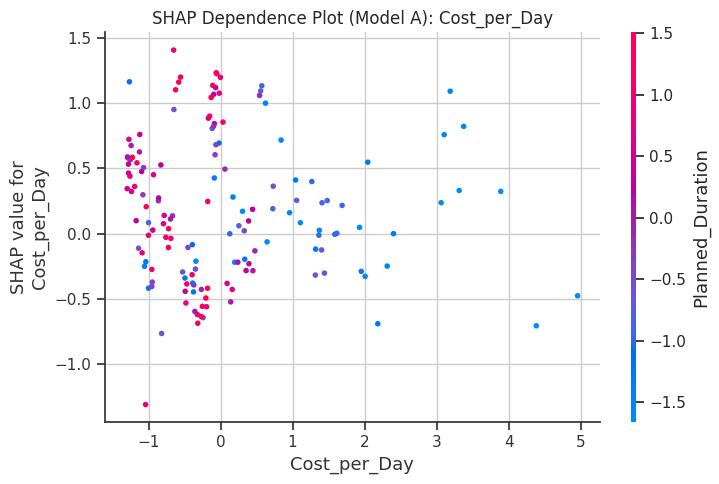

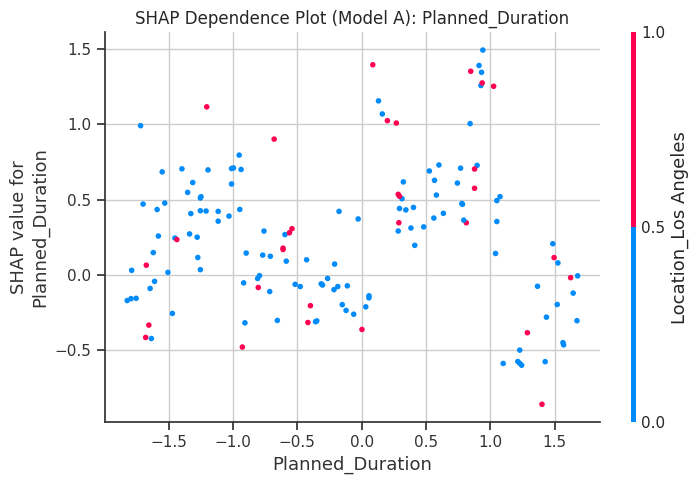

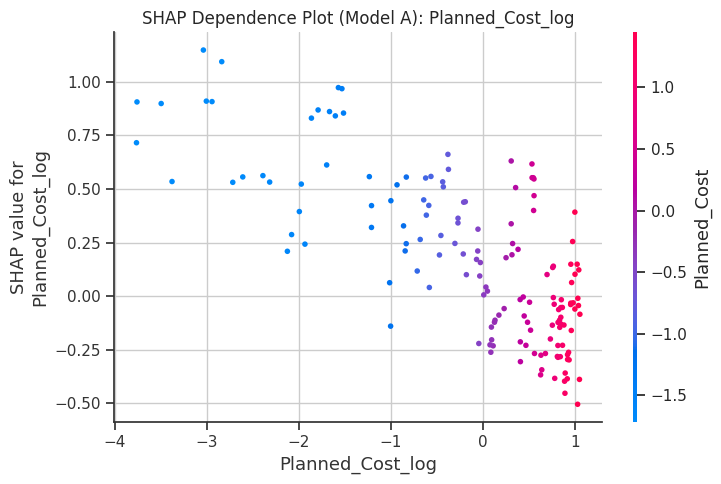

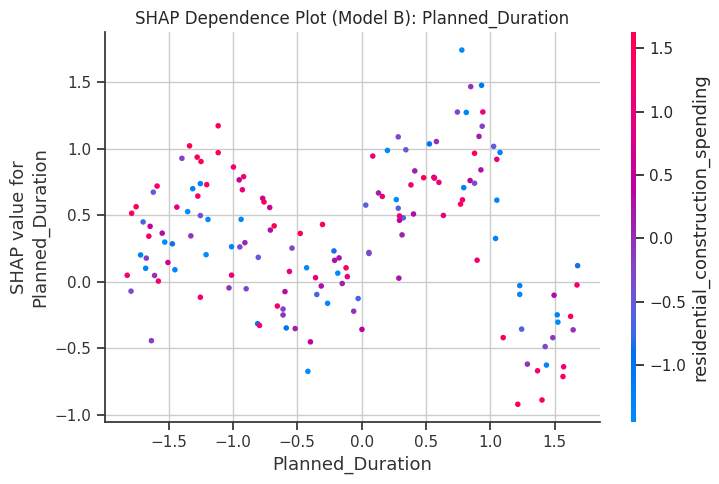

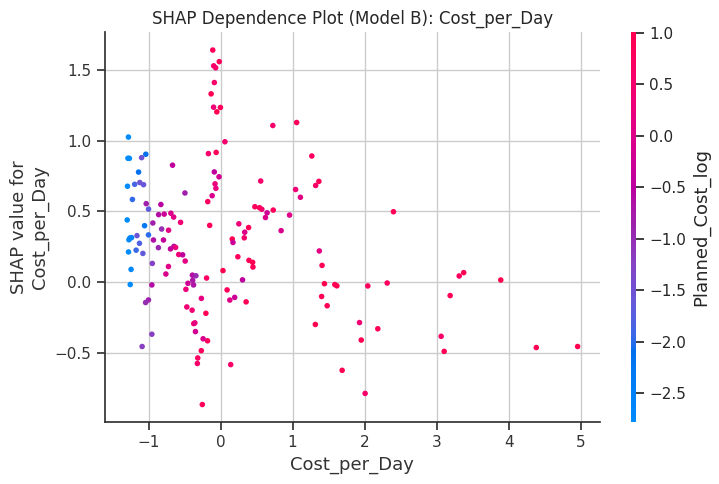

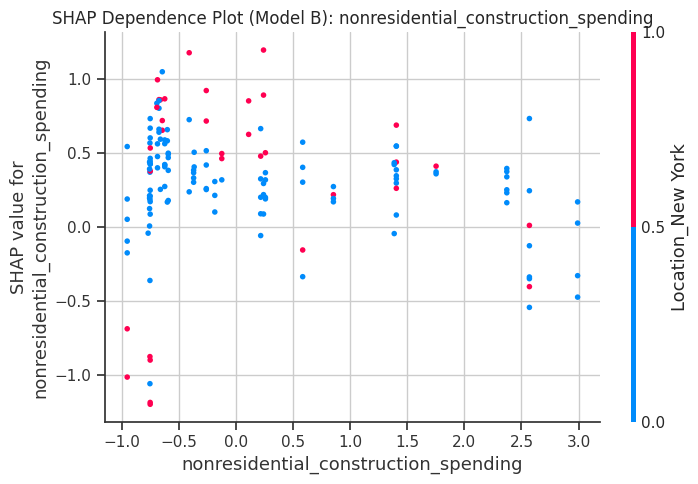

In [154]:
# Generate Dependence plots for Model A and Model B

plot_top_dependence(
    shap_values_A,
    X_A_test_df,
    ranking_A,
    "Model A"
)

plot_top_dependence(
    shap_values_B,
    X_B_test_df,
    ranking_B,
    "Model B"
)

In [155]:
# Save SHAP Summary Plots
import shap

def save_shap_summary(shap_values, X_processed_df, filename):
    shap.summary_plot(shap_values, X_processed_df, show=False)
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")

save_shap_summary(shap_values_A, X_A_test_df, "shap_summary_ModelA.png")
save_shap_summary(shap_values_B, X_B_test_df, "shap_summary_ModelB.png")

Saved: chapter4_figures/shap_summary_ModelA.png
Saved: chapter4_figures/shap_summary_ModelB.png


In [156]:
# Save SHAP Dependence Plots
def save_dependence_plot(feature, shap_values, X_processed_df, filename):
    shap.dependence_plot(feature, shap_values, X_processed_df, show=False)
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")

for feature in ranking_A["Feature"].head(3):
    save_dependence_plot(feature, shap_values_A, X_A_test_df,
                         f"shap_dependence_ModelA_{feature}.png")

for feature in ranking_B["Feature"].head(3):
    save_dependence_plot(feature, shap_values_B, X_B_test_df,
                         f"shap_dependence_ModelB_{feature}.png")

Saved: chapter4_figures/shap_dependence_ModelA_Cost_per_Day.png
Saved: chapter4_figures/shap_dependence_ModelA_Planned_Duration.png
Saved: chapter4_figures/shap_dependence_ModelA_Planned_Cost_log.png
Saved: chapter4_figures/shap_dependence_ModelB_Planned_Duration.png
Saved: chapter4_figures/shap_dependence_ModelB_Cost_per_Day.png
Saved: chapter4_figures/shap_dependence_ModelB_nonresidential_construction_spending.png


##### 8.4 SHAP Local Explanations - Waterfall Plots

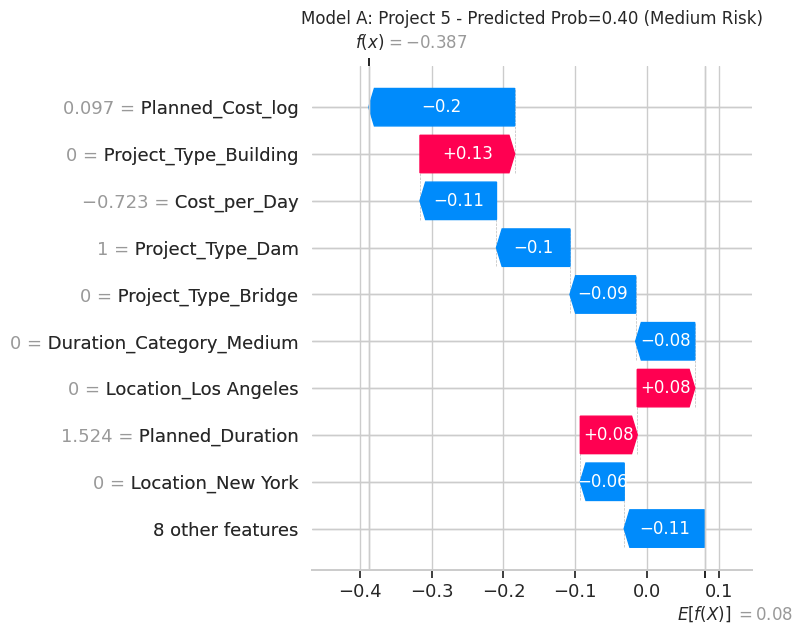

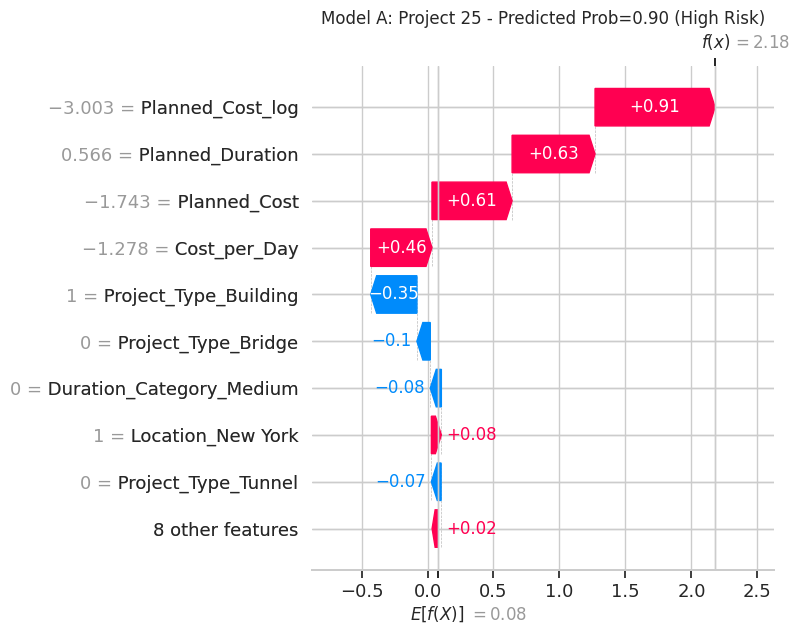

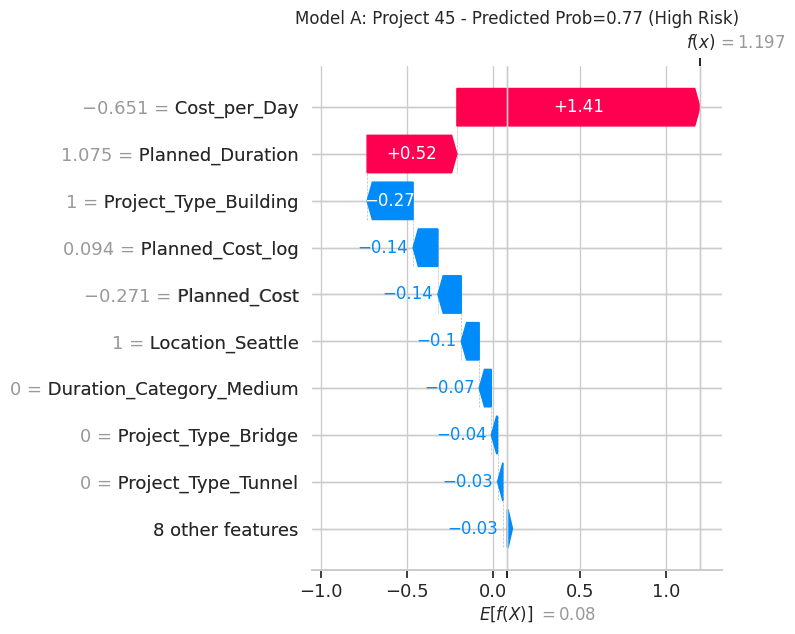

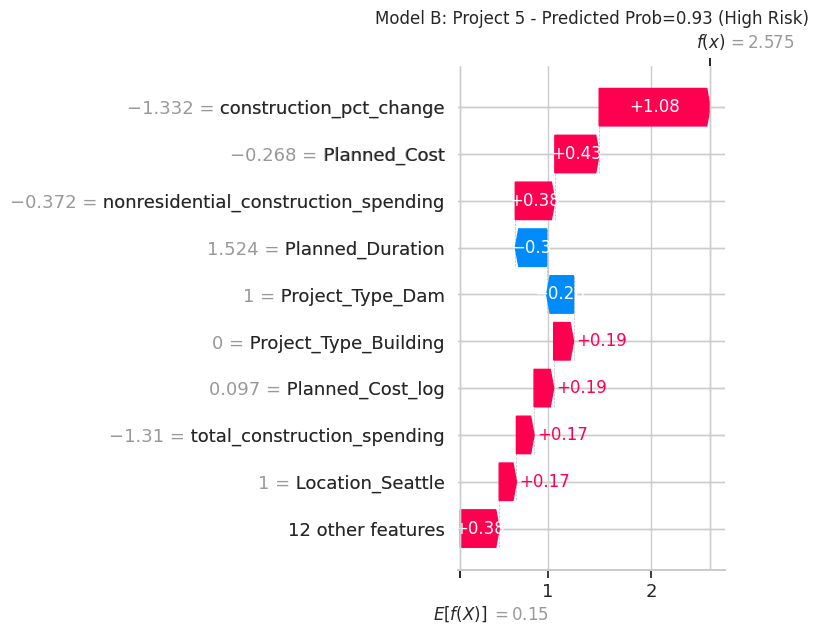

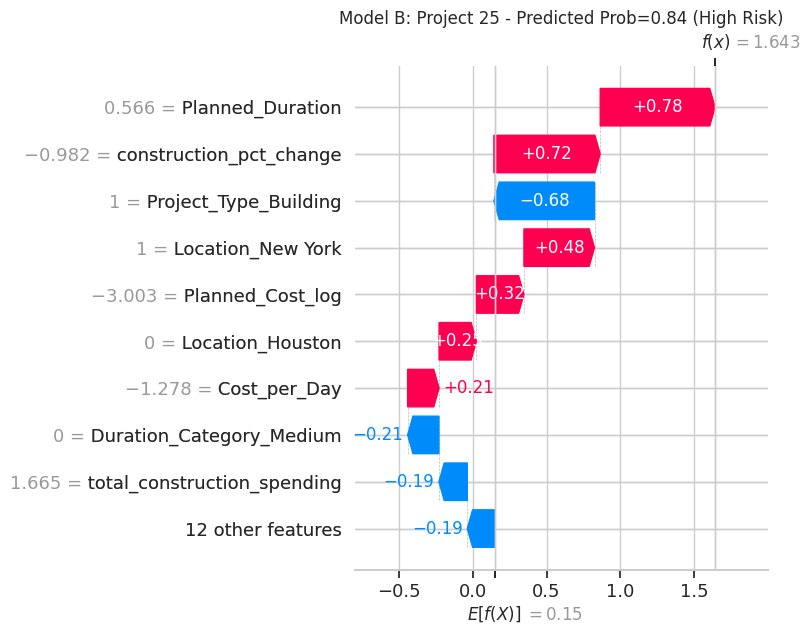

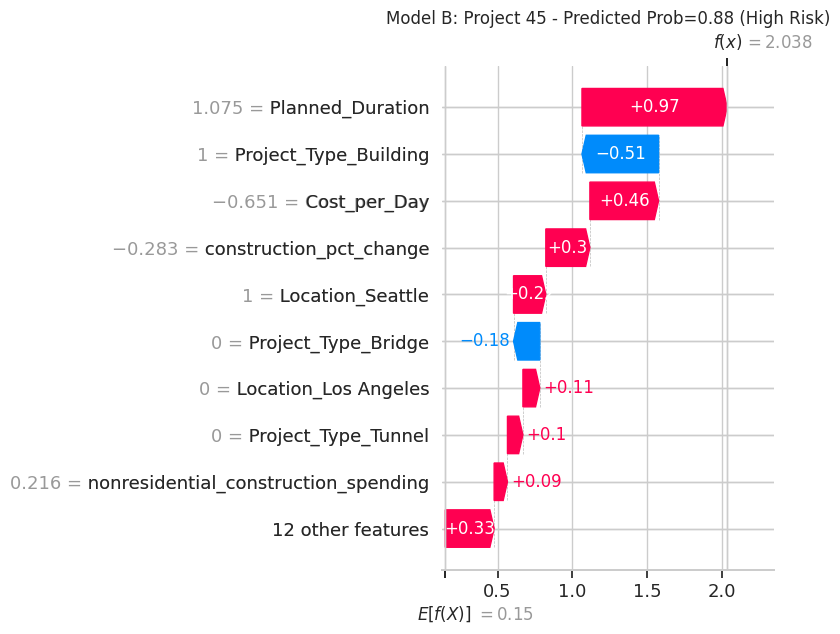

In [157]:
# Waterfall Plots
def plot_local_explanations(model, explainer, shap_values, X_processed, X_processed_df,
                            indices, model_label):
    predictions = model.predict_proba(X_processed)[:, 1]

    for idx in indices:
        prob = predictions[idx]
        risk_label = "Low Risk" if prob < 0.3 else "Medium Risk" if prob <= 0.6 else "High Risk"

        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[idx],
                base_values=explainer.expected_value,
                data=X_processed_df.iloc[idx],
                feature_names=X_processed_df.columns.tolist()
            ),
            show=False
        )
        plt.title(f"{model_label}: Project {idx} - Predicted Prob={prob:.2f} ({risk_label})")
        plt.tight_layout()
        plt.show()

example_indices = [5, 25, 45]

plot_local_explanations(
    best_model_A, explainer_A, shap_values_A,
    X_A_test_processed, X_A_test_df, example_indices, "Model A"
)

plot_local_explanations(
    best_model_B, explainer_B, shap_values_B,
    X_B_test_processed, X_B_test_df, example_indices, "Model B"
)

In [158]:
# Save SHAP Local Explanations
def save_local_explanation(explainer, shap_values, X_processed_df, idx, filename):
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_processed_df.iloc[idx],
            feature_names=X_processed_df.columns.tolist()
        ),
        show=False
    )
    path = os.path.join(SHAP_LOCAL_DIR, filename)
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")

# Example indices
example_indices = [5, 25, 45]

for idx in example_indices:
    save_local_explanation(explainer_A, shap_values_A, X_A_test_df, idx,
                           f"shap_local_ModelA_project_{idx}.png")

    save_local_explanation(explainer_B, shap_values_B, X_B_test_df, idx,
                           f"shap_local_ModelB_project_{idx}.png")


Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/figures/shap_local_examples/shap_local_ModelA_project_5.png
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/figures/shap_local_examples/shap_local_ModelB_project_5.png
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/figures/shap_local_examples/shap_local_ModelA_project_25.png
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/figures/shap_local_examples/shap_local_ModelB_project_25.png
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/figures/shap_local_examples/shap_local_ModelA_project_45.png
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/figures/shap_local_examples/shap_local_ModelB_project_45.png


##### 8.5 Calibration Curves and Brier Score

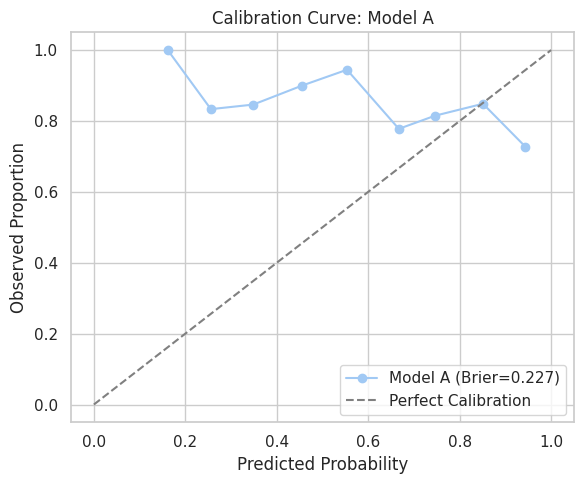

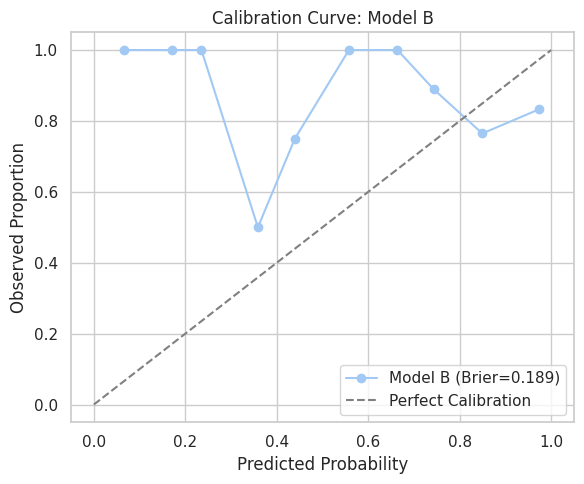

In [159]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def plot_calibration(model, X_processed, y_true, label):
    y_prob = model.predict_proba(X_processed)[:, 1]

    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    brier = brier_score_loss(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(prob_pred, prob_true, marker="o", label=f"{label} (Brier={brier:.3f})")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect Calibration")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Proportion")
    plt.title(f"Calibration Curve: {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_calibration(best_model_A, X_A_test_processed, y_test, "Model A")
plot_calibration(best_model_B, X_B_test_processed, y_test, "Model B")

In [160]:
# Save Calibration Curves
from sklearn.calibration import calibration_curve

def save_calibration_curve(y_true, y_proba, label, filename):
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10)

    plt.figure(figsize=(6,5))
    plt.plot(prob_pred, prob_true, marker="o", label=label)
    plt.plot([0,1], [0,1], "--", color="gray")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.title(f"Calibration Curve: {label}")
    plt.legend()

    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")

save_calibration_curve(y_test, best_model_A.predict_proba(X_A_test_processed)[:,1],
                       "Model A", "calibration_ModelA.png")

save_calibration_curve(y_test, best_model_B.predict_proba(X_B_test_processed)[:,1],
                       "Model B", "calibration_ModelB.png")

Saved: chapter4_figures/calibration_ModelA.png
Saved: chapter4_figures/calibration_ModelB.png


##### 8.6 Precision-Recall Curves

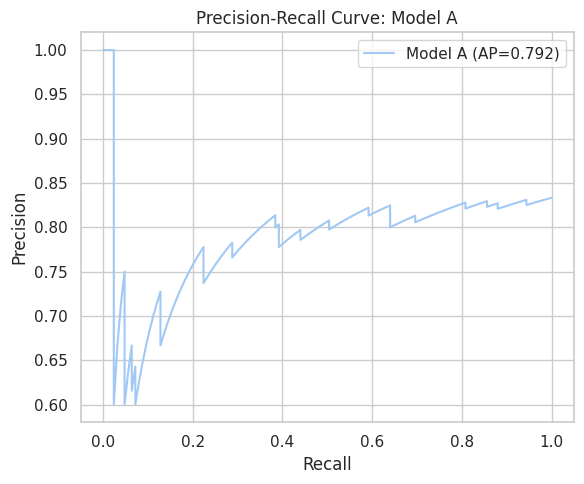

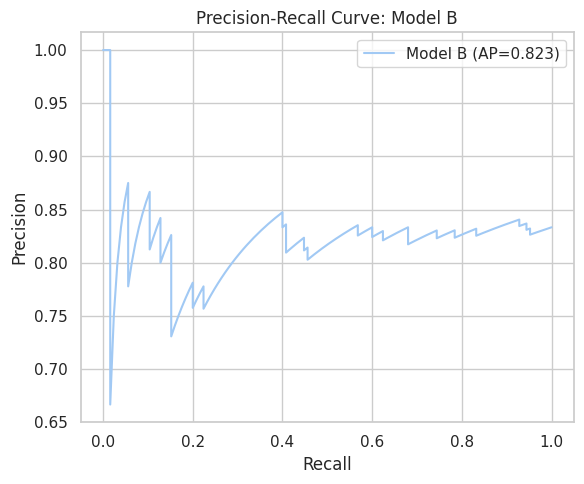

In [161]:
# Precision-Recall
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curve(model, X_processed, y_true, label):
    y_prob = model.predict_proba(X_processed)[:, 1]

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    avg_precision = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"{label} (AP={avg_precision:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve: {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pr_curve(best_model_A, X_A_test_processed, y_test, "Model A")
plot_pr_curve(best_model_B, X_B_test_processed, y_test, "Model B")

In [162]:
# Save PRecision-Recall curves
from sklearn.metrics import precision_recall_curve, average_precision_score

def save_pr_curve(y_true, y_proba, label, filename):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"{label} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve: {label}")
    plt.legend()

    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")

save_pr_curve(y_test, best_model_A.predict_proba(X_A_test_processed)[:,1], "Model A", "pr_curve_ModelA.png")
save_pr_curve(y_test, best_model_B.predict_proba(X_B_test_processed)[:,1], "Model B", "pr_curve_ModelB.png")

Saved: chapter4_figures/pr_curve_ModelA.png
Saved: chapter4_figures/pr_curve_ModelB.png


##### 8.7 Risk Category Validation

In [163]:
def validate_risk_categories(model, X_processed, y_true, label):
    y_prob = model.predict_proba(X_processed)[:, 1]

    df = pd.DataFrame({"prob": y_prob, "actual": y_true})

    df["risk_category"] = pd.cut(
        df["prob"],
        bins=[-0.001, 0.30, 0.60, 1.0],
        labels=["Low Risk (<30%)", "Medium Risk (30–60%)", "High Risk (>60%)"]
    )

    validation_table = df.groupby("risk_category")["actual"].agg(
        Total_Projects="count",
        Actual_Overrun_Rate="mean"
    ).reset_index()

    validation_table["Model"] = label
    return validation_table

risk_validation_A = validate_risk_categories(best_model_A, X_A_test_processed, y_test, "Model A")
risk_validation_B = validate_risk_categories(best_model_B, X_B_test_processed, y_test, "Model B")

risk_validation_combined = pd.concat([risk_validation_A, risk_validation_B]).reset_index(drop=True)

In [164]:
risk_validation_combined

,risk_category,Total_Projects,Actual_Overrun_Rate,Model
0,Low Risk (<30%),9,0.888889,Model A
1,Medium Risk (30–60%),41,0.902439,Model A
2,High Risk (>60%),100,0.800000,Model A
3,Low Risk (<30%),6,1.000000,Model B
4,Medium Risk (30–60%),10,0.700000,Model B
5,High Risk (>60%),134,0.835821,Model B


In [165]:
# Save Outputs

def save_dataframe(df, filename):
    path = os.path.join(TABLE_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")

# Full metrics summary
save_dataframe(metrics_summary, "metrics_summary.csv")

# Baseline vs Tuned comparisons
save_dataframe(baseline_vs_tuned_A, "baseline_vs_tuned_A.csv")
save_dataframe(baseline_vs_tuned_B, "baseline_vs_tuned_B.csv")

# Model A vs Model B validation comparison
save_dataframe(comparison_tuned_val, "comparison_tuned_validation.csv")

# Final test results
save_dataframe(pd.DataFrame(final_test_A).T, "final_test_ModelA.csv")
save_dataframe(pd.DataFrame(final_test_B).T, "final_test_ModelB.csv")

# Risk category validation
save_dataframe(risk_validation_combined, "risk_category_validation.csv")

# SHAP feature ranking
save_dataframe(feature_ranking_table, "shap_feature_ranking.csv")

Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/tables/metrics_summary.csv
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/tables/baseline_vs_tuned_A.csv
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/tables/baseline_vs_tuned_B.csv
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/tables/comparison_tuned_validation.csv
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/tables/final_test_ModelA.csv
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/tables/final_test_ModelB.csv
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/tables/risk_category_validation.csv
Saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/tables/shap_feature_ranking.csv


In [166]:
# SHAP based Sanity Check

print("=== SHAP Top Features Model A ===")
print(ranking_A.head(5))

print("=== SHAP Top Features Model B ===")
print(ranking_B.head(5))

=== SHAP Top Features Model A ===
               Feature  Mean Absolute SHAP    Model
0         Cost_per_Day            0.464518  Model A
1     Planned_Duration            0.428144  Model A
2     Planned_Cost_log            0.325027  Model A
3         Planned_Cost            0.249473  Model A
4  Project_Type_Bridge            0.133340  Model A
=== SHAP Top Features Model B ===
                                Feature  Mean Absolute SHAP    Model
0                      Planned_Duration            0.509273  Model B
1                          Cost_per_Day            0.449440  Model B
2  nonresidential_construction_spending            0.442492  Model B
3               construction_pct_change            0.430208  Model B
4                          Planned_Cost            0.395643  Model B


In [167]:
# Save a Log file Recording the Workflow
log_content = f"""
Workflow Execution Log

Best Selected Model A: {best_algo_A}
Best Selected Model B: {best_algo_B}

Number of Test Projects: {len(y_test)}
Class Balance: {y_test.value_counts().to_dict()}

Saved Artifacts:
- Trained models
- Metric tables
- ROC curves
- Confusion matrices
- SHAP summary plots
- SHAP dependence plots
- SHAP local explanations
- Precision-recall curves
- Calibration curves
- Risk category validation
"""

log_path = os.path.join(LOG_DIR, "workflow_log.txt")

with open(log_path, "w") as f:
    f.write(log_content)

print(f"Log saved: {log_path}")


Log saved: /content/drive/MyDrive/CostOverrunPrediction/outputs/logs/workflow_log.txt


The SHAP interpretability outputs added critical analytical depth to the findings.

- The global SHAP results in Model A confirmed that project scale and cost intensity, particularly Planned_Cost_log and Cost_per_Day, dominate predictive contributions.

- In Model B, Planned_Duration became the leading feature, and macroeconomic variables such as nonresidential_construction_spending and construction_pct_change emerged as significant contributors.

- Local SHAP examples further supported this finding by revealing that predictions for individual projects incorporated meaningful contributions from Tier 2 features.

- Model B demonstrated a lower Brier score and closer alignment with the diagonal reference line, indicating that macroeconomic indicators improve probabilistic reliability.

- The risk categorization framework retained analytical value for practical decision-support, the calibration results indicate that predicted probabilities must be interpreted cautiously.



###**9. Conclusion**

Finally, the objective of incorporating explainability techniques was achieved through the integration of SHAP-based interpretability into the framework.

- Global SHAP outputs revealed that project scale, cost intensity, and duration were the strongest predictors in Model A.

- In Model B, macroeconomic indicators such as non-residential construction spending and construction percent change were the meaningful contributors, indicating that external market conditions play a direct role in the model’s decision-making process.

- Local SHAP explanations provided transparent, project-level insights into individual predictions, which shows the interpretability required for real-time decision support.

Together, these outputs translate the framework from a predictive engine into a transparent, decision-oriented tool suitable for adoption by construction professional.
The developed framework demonstrates that early-stage cost overrun prediction can be effectively supported by combining internal project features with external macroeconomic indicators, evaluated through a rigorous ablation-based methodology, and interpreted through SHAP-based explainability. The framework achieves the study’s aim of producing a transparent, methodologically rigorous, and practically useful early-stage cost overrun prediction system

### **10. Future Recommendations**

- Apply the framework to larger and more diverse construction datasets to strengthen generalisability, particularly those containing balance class distributions and richer categorical variability.

- Extending the framework to include additional macroeconomic indicators such as material price indices, labour cost indicators, or supply chain volatility metrics, could increase its predictive performance and improve calibration.

- Advanced probability calibration techniques such as isotonic regression or temperature scaling could be explored to enhance the reliability of risk category outputs.

- Hybrid frameworks that combine deep learning representations with tree-based interpretability techniques could provide additional insights into complex non-linear relationships.

- Extending the SHAP-based interpretability to include counterfactual explanations, feature interaction visualisations, and stakeholder-oriented decision-support tools which could enhance the framework’s real-world applicability



These recommendations set a clear path for further research into interpretable, early-stage, and macroeconomic-aware predictive analytics for construction cost overrun risk. The present study contributes a foundation for future research and demonstrates that integrating internal and external factors within a transparent framework offers a valuable pathway for improving proactive cost overrun risk management in the construction industry.